# Exploratory Data Analysis — Synthetic Multimodal Educational Administrative Behaviour

**Research context:** *Multimodal Representation Learning for Educational Administrative Behavior
Analysis: A Transformer-Based Fusion Framework.*

Having established the dataset's **integrity and validity** in the companion audit notebook, this
notebook conducts a thorough, publication-quality **Exploratory Data Analysis (EDA)**. Where the audit
asked *"is the data trustworthy?"*, the EDA asks *"what does the data tell us?"* — surfacing the
distributions, relationships, group differences, temporal patterns and multimodal structure that
should inform feature engineering and model design for the fusion framework.

Each record is one **administrator × month** observation combining three modalities (text,
administrative logs, teacher surveys) and derived behavioural labels.

### Analysis roadmap
1. Dataset structure & first glimpse
2. Missing-value landscape
3. Univariate analysis — numeric features
4. Univariate analysis — categorical features
5. Behavioural labels: deep dive
6. Correlation & bivariate relationships
7. Behaviour-category profiling
8. Demographic analysis
9. Administrative-log exploration
10. Survey (psychometric) exploration
11. Text-modality exploration
12. Temporal exploration
13. Interactive visual analytics (Plotly)
14. Multidimensional view (PCA)
15. Key insights & takeaways

Every figure is saved under `output/eda/` at high resolution; interactive charts are additionally
exported as standalone HTML.

# Imports, Configuration & Helpers

We load the scientific-plotting stack and define a consistent, publication-quality visual style,
a fixed colour mapping for the five behaviour categories (used throughout for visual continuity),
and small reusable helpers (`save_fig`, `savetable`, `save_plotly`, `insight`).

In [1]:
import os
import re
import json
import warnings
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

# --- Visual style -----------------------------------------------------------
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
matplotlib.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "figure.figsize": (10, 6),
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "font.family": "DejaVu Sans", "figure.autolayout": True,
})
pio.templates.default = "plotly_white"
PALETTE = sns.color_palette("deep")

CATEGORY_ORDER = ["Highly Effective", "Effective", "Average", "Overloaded", "Needs Improvement"]
CATEGORY_COLORS = {
    "Highly Effective": "#2ca02c",
    "Effective": "#1f77b4",
    "Average": "#7f7f7f",
    "Overloaded": "#ff7f0e",
    "Needs Improvement": "#d62728",
}
print("Environment ready.")

Environment ready.


In [2]:
# --- Output directories -----------------------------------------------------
DATA_DIR = Path("output")
EDA_DIR = DATA_DIR / "eda"
FIG_DIR = EDA_DIR / "figures"
TABLE_DIR = EDA_DIR / "tables"
HTML_DIR = EDA_DIR / "interactive"
for d in (EDA_DIR, FIG_DIR, TABLE_DIR, HTML_DIR):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str) -> Path:
    """Save a matplotlib figure to the EDA figures directory."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    return path

def savetable(df: pd.DataFrame, name: str, index: bool = True) -> Path:
    """Persist a DataFrame as a CSV under the EDA tables directory."""
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    return path

def save_plotly(fig, name: str) -> Path:
    """Persist an interactive Plotly figure as a standalone HTML file."""
    path = HTML_DIR / f"{name}.html"
    fig.write_html(str(path), include_plotlyjs="cdn")
    return path

def insight(text: str) -> None:
    """Print a clearly delimited 'insight' box after an analysis."""
    print("\n" + "\u2550" * 80)
    print("INSIGHT")
    print("\u2500" * 80)
    for line in text.strip().splitlines():
        print("  " + line.strip())
    print("\u2550" * 80 + "\n")

print(f"EDA artefacts -> {EDA_DIR.resolve()}")

EDA artefacts -> /projects/sandbox/Administrative_behavioural_analysis/output/eda


# Data Loading

We load the fused monthly dataset and the three raw modality tables, plus the generation metadata.
Column groups are inferred once and reused across the analysis.

In [3]:
df = pd.read_csv(DATA_DIR / "monthly_dataset.csv")
logs = pd.read_csv(DATA_DIR / "administrative_logs.csv")
text = pd.read_csv(DATA_DIR / "text_documents.csv")
survey = pd.read_csv(DATA_DIR / "survey_responses.csv")
agg = pd.read_csv(DATA_DIR / "survey_aggregates.csv")
with open(DATA_DIR / "metadata.json", encoding="utf-8") as fh:
    META = json.load(fh)

ID_COLS = ["admin_id", "month", "month_step"]
LABEL_SCORES = ["leadership_score", "communication_score", "administrative_efficiency",
                "stress_score", "engagement_score"]
CATEGORY_COL = "behaviour_category"
DEMOGRAPHICS = [c for c in ["gender", "age", "years_experience", "institution_type",
                            "department", "designation"] if c in df.columns]
LOG_FEATURES = [c for c in logs.columns if c not in ID_COLS]
SURVEY_ITEMS = [c for c in survey.columns if c not in ID_COLS + ["teacher_id"]]
SURVEY_MEAN_COLS = [f"{it}_mean" for it in SURVEY_ITEMS if f"{it}_mean" in df.columns]
TEXT_NUM = [c for c in df.columns if c.startswith("text_") and pd.api.types.is_numeric_dtype(df[c])]
NUMERIC_COLS = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "month_step"]

# Ensure category ordering is consistent for grouped plots.
df[CATEGORY_COL] = pd.Categorical(df[CATEGORY_COL], categories=CATEGORY_ORDER, ordered=True)

print("Loaded:")
for nm, f in [("monthly_dataset", df), ("administrative_logs", logs), ("text_documents", text),
              ("survey_responses", survey), ("survey_aggregates", agg)]:
    print(f"  {nm:20s} {f.shape[0]:>7,d} x {f.shape[1]:>3d}")
print(f"\nAdministrators: {df['admin_id'].nunique()} | Months: {df['month_step'].nunique()}")

Loaded:
  monthly_dataset        3,600 x  91
  administrative_logs    3,600 x  25
  text_documents         7,003 x  15
  survey_responses      72,000 x  18
  survey_aggregates      3,600 x  46

Administrators: 300 | Months: 12


# 1 — Dataset Structure & First Glimpse

We inspect the shape, data types, per-column memory footprint and a sample of records to build
intuition for the feature space before diving into distributions.

In [4]:
print("Fused dataset shape:", df.shape)
dtypes_summary = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="n_columns")
display(dtypes_summary)

glimpse = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "sample_value": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
savetable(glimpse, "section01_column_glimpse")
display(glimpse.head(30))
display(df.head(4))

Fused dataset shape: (3600, 91)


,dtype,n_columns
0,float64,76
1,str,11
2,int64,3
3,category,1


,dtype,n_unique,n_missing,pct_missing,sample_value
admin_id,str,300,0,0.00,A0001
month,str,12,0,0.00,2024-01
month_step,int64,12,0,0.00,1
meetings_conducted,float64,43,98,2.72,20.0
meetings_attended,float64,32,81,2.25,15.0
reports_submitted,float64,24,94,2.61,8.0
approvals_processed,float64,56,87,2.42,29.0
leave_requests_processed,float64,22,91,2.53,4.0
pending_tasks,float64,30,83,2.31,13.0
overdue_tasks,float64,18,75,2.08,5.0


,admin_id,month,month_step,meetings_conducted,meetings_attended,reports_submitted,approvals_processed,leave_requests_processed,pending_tasks,overdue_tasks,active_projects,average_response_hours,average_task_completion_days,attendance_percentage,punctuality_percentage,working_hours_per_week,meetings_per_week,policy_decisions,emergency_decisions,delegated_tasks,office_visits,faculty_interactions,student_interactions,budget_requests,complaint_resolutions,n_respondents,communicates_clearly_mean,communicates_clearly_median,communicates_clearly_std,provides_feedback_mean,provides_feedback_median,provides_feedback_std,approachable_mean,approachable_median,approachable_std,motivates_staff_mean,motivates_staff_median,motivates_staff_std,supports_teachers_mean,supports_teachers_median,supports_teachers_std,encourages_innovation_mean,encourages_innovation_median,encourages_innovation_std,fairness_mean,fairness_median,fairness_std,transparency_mean,transparency_median,transparency_std,responds_quickly_mean,responds_quickly_median,responds_quickly_std,manages_workload_mean,manages_workload_median,manages_workload_std,resolves_conflicts_mean,resolves_conflicts_median,resolves_conflicts_std,organizes_effectively_mean,organizes_effectively_median,organizes_effectively_std,overall_satisfaction_mean,overall_satisfaction_median,overall_satisfaction_std,overall_effectiveness_mean,overall_effectiveness_median,overall_effectiveness_std,leadership_score,communication_score,administrative_efficiency,stress_score,engagement_score,behaviour_category,text_document_count,text_avg_word_count,text_avg_sentiment,text_avg_positive_ratio,text_avg_negative_ratio,text_avg_readability,text_dominant_type,text_dominant_topic,text_dominant_urgency,text_dominant_style,name,gender,age,years_experience,institution_type,department,designation
0,A0001,2024-01,1,20.0,15.0,8.0,29.0,4.0,13.0,5.0,6.0,20.50,6.40,85.69,71.11,59.10,4.62,7.0,6.0,7.0,19.0,16.0,NaN,4.0,3.0,20.0,3.20,3.0,0.600,NaN,3.0,0.669,2.85,3.0,0.654,3.55,3.5,0.589,3.75,4.0,0.536,3.65,4.0,0.477,3.60,4.0,0.583,3.25,NaN,0.829,2.45,2.0,0.740,2.60,3.0,NaN,3.40,3.5,0.800,3.1,3.0,0.831,3.15,3.0,0.654,3.65,4.0,0.654,66.38,54.63,49.91,92.87,66.34,Overloaded,1.0,352.0000,0.0065,0.0142,0.0199,10.5300,Notice,admission process,Critical,neutral-informal-directive-urgent,Alexander Hill,Male,48,3,Community College,Research & Development,Vice Principal
1,A0001,2024-02,2,20.0,21.0,6.0,30.0,5.0,13.0,6.0,8.0,37.17,6.40,79.57,69.09,51.32,4.62,1.0,NaN,9.0,16.0,18.0,23.0,2.0,9.0,20.0,3.20,3.0,0.600,NaN,NaN,0.640,2.70,3.0,0.640,3.40,3.0,0.735,3.45,3.0,0.669,3.70,4.0,0.900,3.55,4.0,NaN,3.25,3.0,0.829,2.10,NaN,0.768,2.40,2.0,0.860,3.30,3.0,NaN,2.6,3.0,NaN,3.15,NaN,0.726,3.20,3.0,0.510,69.72,59.39,44.71,89.80,64.32,Overloaded,2.0,372.5000,-0.0750,0.0140,0.0192,9.8000,Meeting Minutes,digital learning,Critical,neutral-professional-directive-urgent,Alexander Hill,Male,48,3,Community College,Research & Development,Vice Principal
2,A0001,2024-03,3,32.0,21.0,8.0,NaN,7.0,17.0,10.0,10.0,16.61,8.75,87.62,61.31,52.39,7.39,4.0,4.0,12.0,15.0,32.0,14.0,3.0,0.0,20.0,3.50,3.5,NaN,3.0,3.0,0.837,2.85,3.0,0.910,3.60,4.0,NaN,3.30,3.5,0.843,3.75,4.0,NaN,3.55,4.0,0.973,3.75,4.0,NaN,2.60,NaN,0.800,2.15,2.0,0.910,3.65,NaN,0.963,3.1,3.0,0.831,3.40,3.0,0.735,NaN,4.0,0.853,65.49,58.76,49.94,92.14,61.81,Overloaded,3.0,316.0000,-0.0408,0.0156,0.0167,0.6633,Notice,examination scheduling,Critical,neutral-professional-directive-urgent,Alexander Hill,Male,48,3,Community College,Research & Development,Vice Principal
3,A0001,2024-04,4,17.0,13.0,7.0,27.0,6.0,9.0,6.0,4.0,12.72,6.92,NaN,81.88,58.33,3.93,4.0,3.0,4.0,27.0,23.0,24.0,4.0,2.0,20.0,3.15,3.0,0.792,3.1,3.0,0.831,2.90,3.0,0.624,3.25,3.0,0.698,3.55,4.0,0.805,3.70,4.0,NaN,3.60,3.0,0.860,3.45,NaN,0.921,2.65,3.0,0.726,2.15,2.0,0.792,3.45,3.0,0.669,2.7,3.0,0.640,3.10,3.0,0.831,3.15,3.0,0.477,66.04,59.03,49.27,94.86,70.32,Overloaded,3.0,322.3333,-0.0095,0.0179,0.0210,6.7467,Academic Report,infrastructure upgrade,Critic

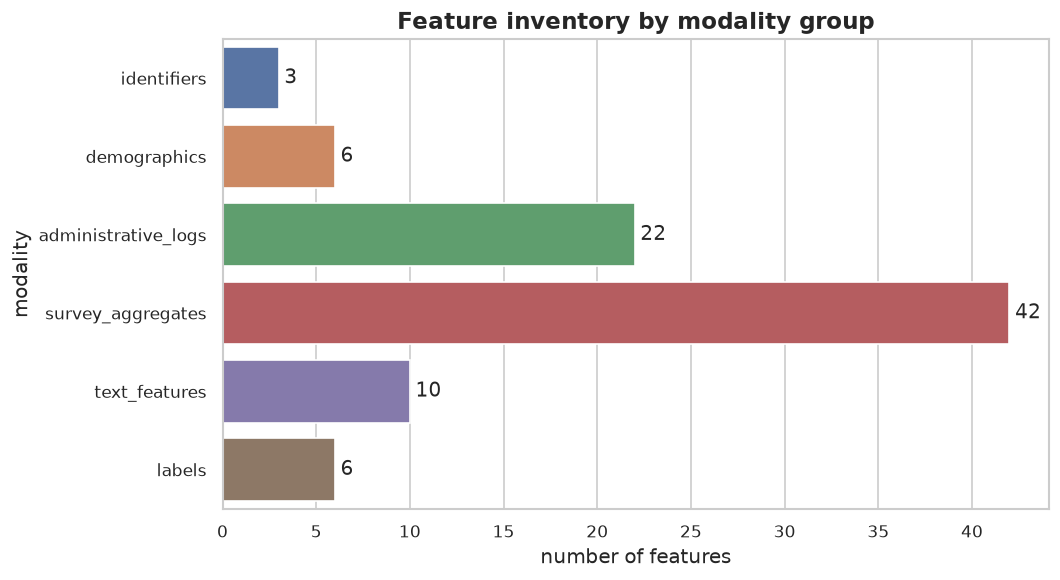


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  The fused dataset couples 22 administrative-log metrics, 14
  aggregated survey items (each with mean/median/std), 6 numeric text descriptors and
  six behavioural labels for 3,600 administrator-month records. This wide, heterogeneous feature
  space is precisely the setting a transformer-based fusion model is designed to exploit.
════════════════════════════════════════════════════════════════════════════════



In [5]:
# Feature inventory by modality group.
groups = {
    "identifiers": ID_COLS,
    "demographics": DEMOGRAPHICS,
    "administrative_logs": LOG_FEATURES,
    "survey_aggregates": [c for c in df.columns if any(c.startswith(it) for it in SURVEY_ITEMS)],
    "text_features": [c for c in df.columns if c.startswith("text_")],
    "labels": LABEL_SCORES + [CATEGORY_COL],
}
inv = pd.DataFrame([{"modality": g, "n_features": len(cols)} for g, cols in groups.items()])
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=inv, y="modality", x="n_features", ax=ax, palette="deep")
for i, v in enumerate(inv["n_features"]):
    ax.text(v + 0.3, i, str(v), va="center")
ax.set_title("Feature inventory by modality group"); ax.set_xlabel("number of features")
save_fig(fig, "section01_feature_inventory"); plt.show()
insight(f"""
The fused dataset couples {len(LOG_FEATURES)} administrative-log metrics, {len(SURVEY_MEAN_COLS)}
aggregated survey items (each with mean/median/std), {len(TEXT_NUM)} numeric text descriptors and
six behavioural labels for {len(df):,} administrator-month records. This wide, heterogeneous feature
space is precisely the setting a transformer-based fusion model is designed to exploit.
""")

# 2 — Missing-Value Landscape

A quick exploratory view of where data is missing. (The audit established the mechanism is
workload-driven / MNAR; here we simply map its extent to know which features may need imputation
before modelling.)

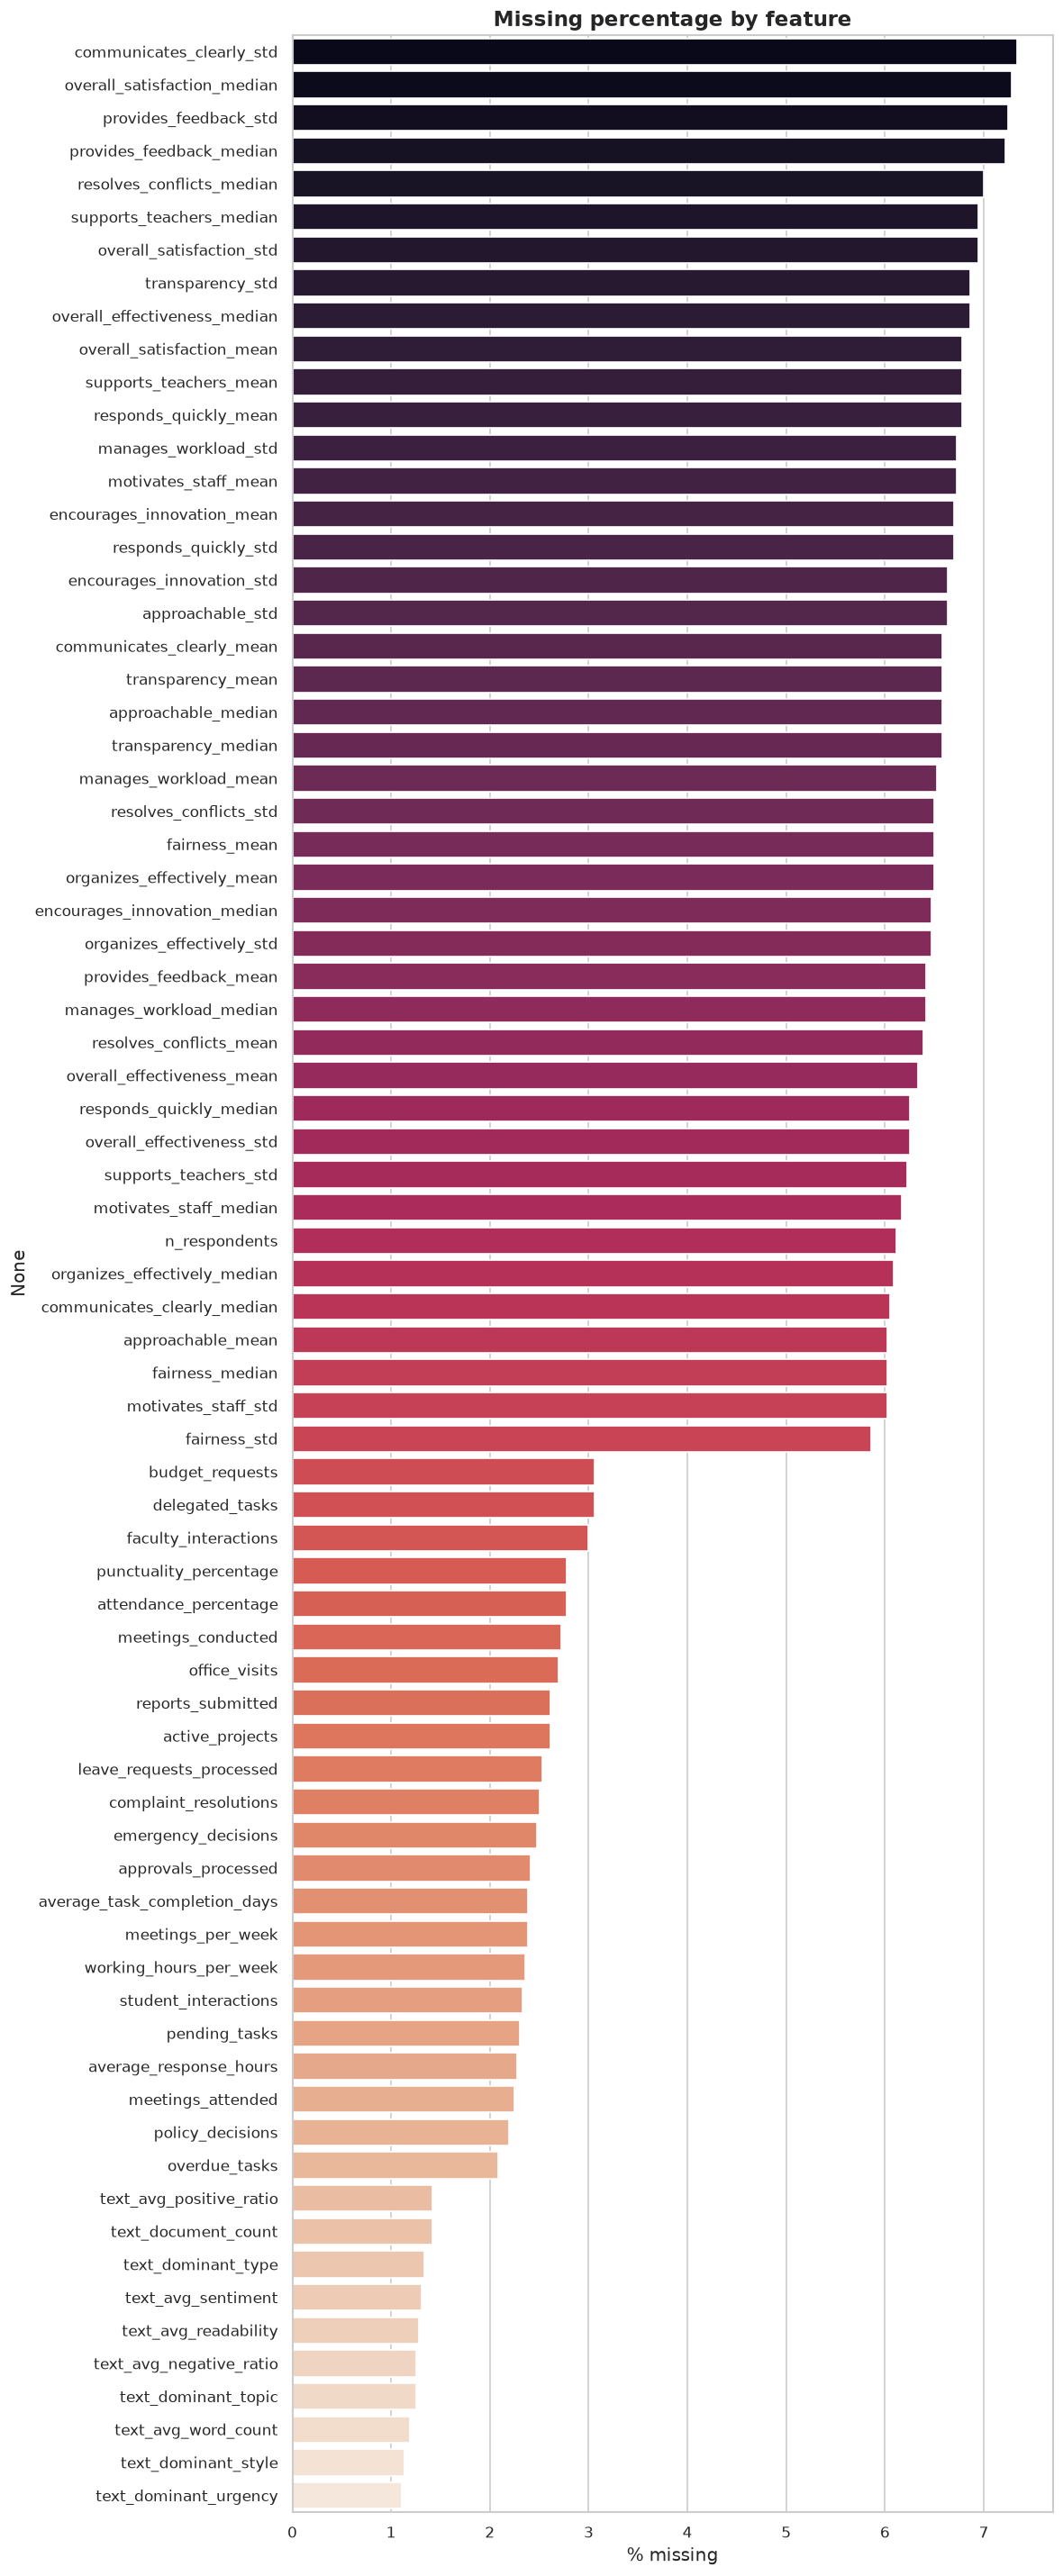


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  75 of 91 columns contain missing values, with the highest around
  7.3%. Missingness is concentrated in survey-aggregate and administrative-log fields;
  identifiers, labels and demographics are complete. Overall completeness is high, so listwise deletion
  remains viable for exploratory cross-sections while modality-aware imputation is preferable for
  modelling.
════════════════════════════════════════════════════════════════════════════════



In [6]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(miss))))
sns.barplot(x=miss.values, y=miss.index, ax=ax, palette="rocket")
ax.set_title("Missing percentage by feature"); ax.set_xlabel("% missing")
save_fig(fig, "section02_missing_by_feature"); plt.show()
savetable(miss.round(3).rename("pct_missing").to_frame(), "section02_missing")

insight(f"""
{len(miss)} of {df.shape[1]} columns contain missing values, with the highest around
{miss.max():.1f}%. Missingness is concentrated in survey-aggregate and administrative-log fields;
identifiers, labels and demographics are complete. Overall completeness is high, so listwise deletion
remains viable for exploratory cross-sections while modality-aware imputation is preferable for
modelling.
""")

# 3 — Univariate Analysis: Numeric Features

We examine the marginal distribution of every numeric feature, organised by modality group. Histograms
with kernel-density overlays reveal shape (skew, modality, bounds); the accompanying skewness table
quantifies asymmetry. This informs transformations (e.g. log for right-skewed counts) prior to modelling.

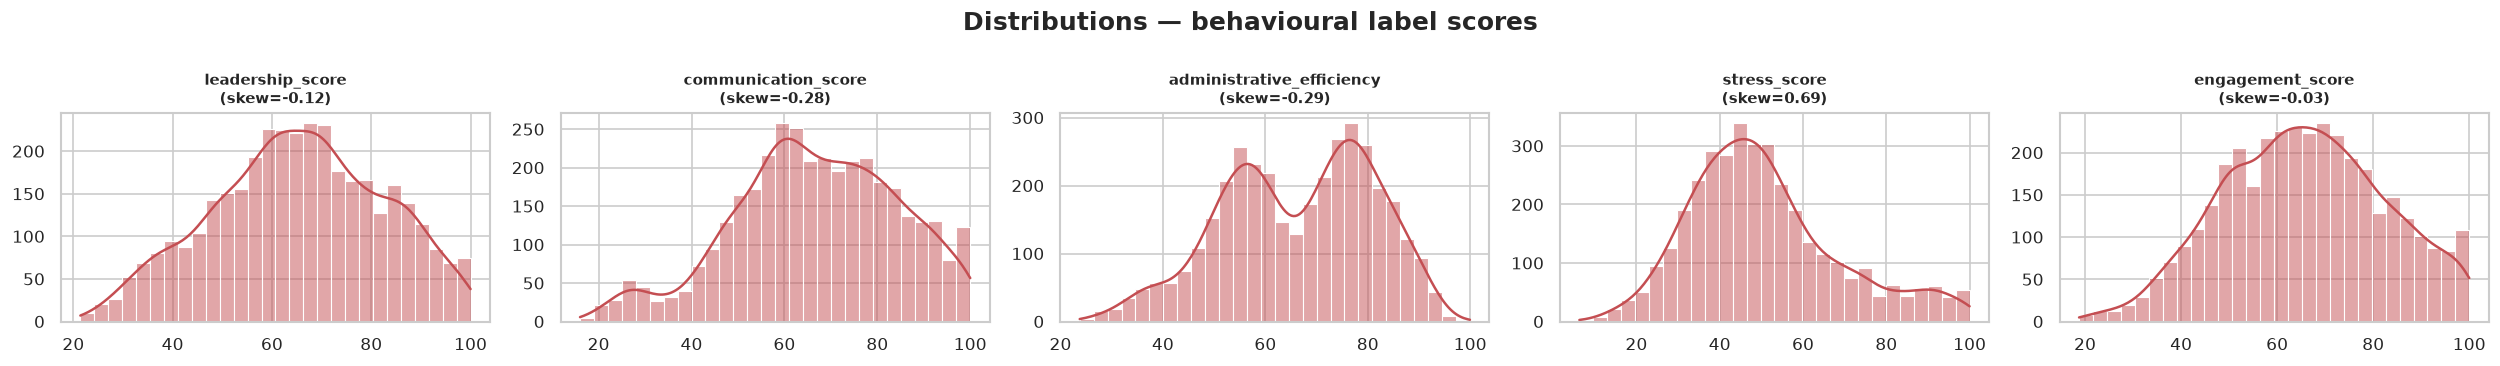

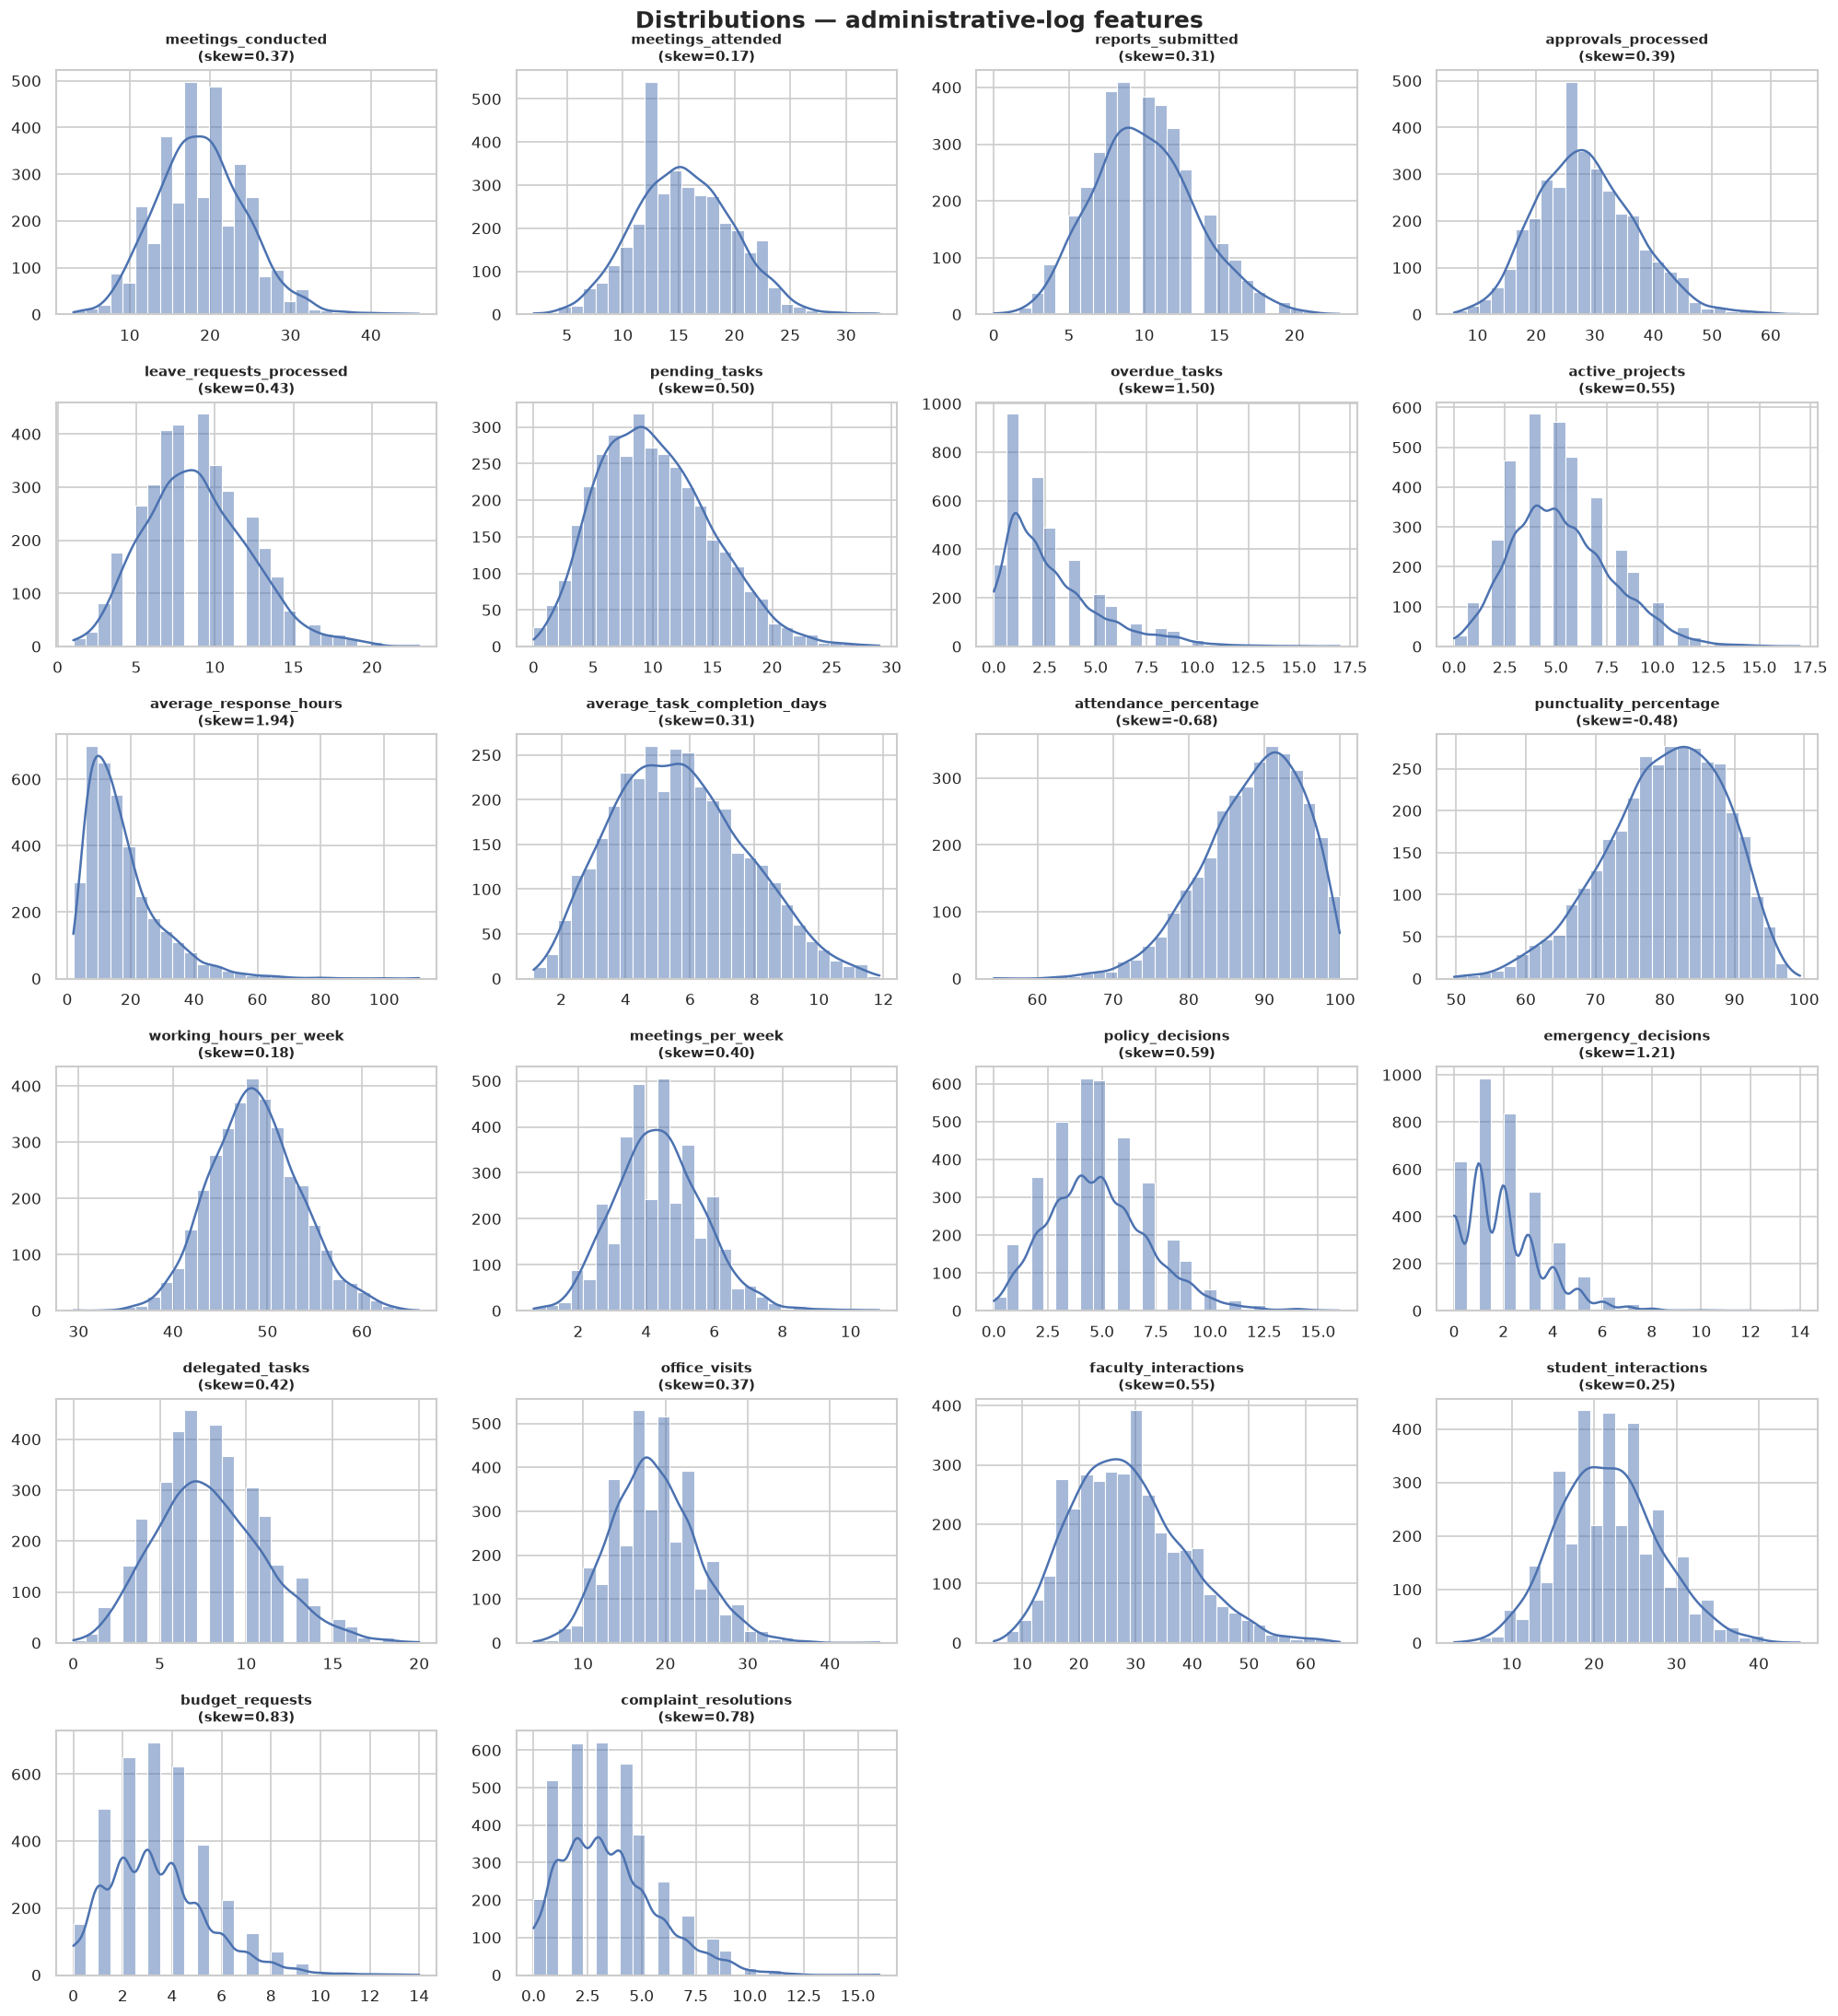

In [7]:
def distribution_grid(columns: list, title: str, fname: str, ncols: int = 4, color=PALETTE[0]):
    """Plot a grid of histogram+KDE panels for a list of numeric columns."""
    columns = [c for c in columns if c in df.columns and df[c].notna().sum() > 5]
    n = len(columns)
    if n == 0:
        return
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.1 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, columns):
        sns.histplot(df[c].dropna(), kde=True, ax=ax, color=color, bins=28)
        sk = stats.skew(df[c].dropna())
        ax.set_title(f"{c}\n(skew={sk:.2f})", fontsize=9)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    save_fig(fig, fname); plt.show()

distribution_grid(LABEL_SCORES, "Distributions — behavioural label scores",
                  "section03_dist_labels", ncols=5, color=PALETTE[3])
distribution_grid(LOG_FEATURES, "Distributions — administrative-log features",
                  "section03_dist_logs", ncols=4, color=PALETTE[0])

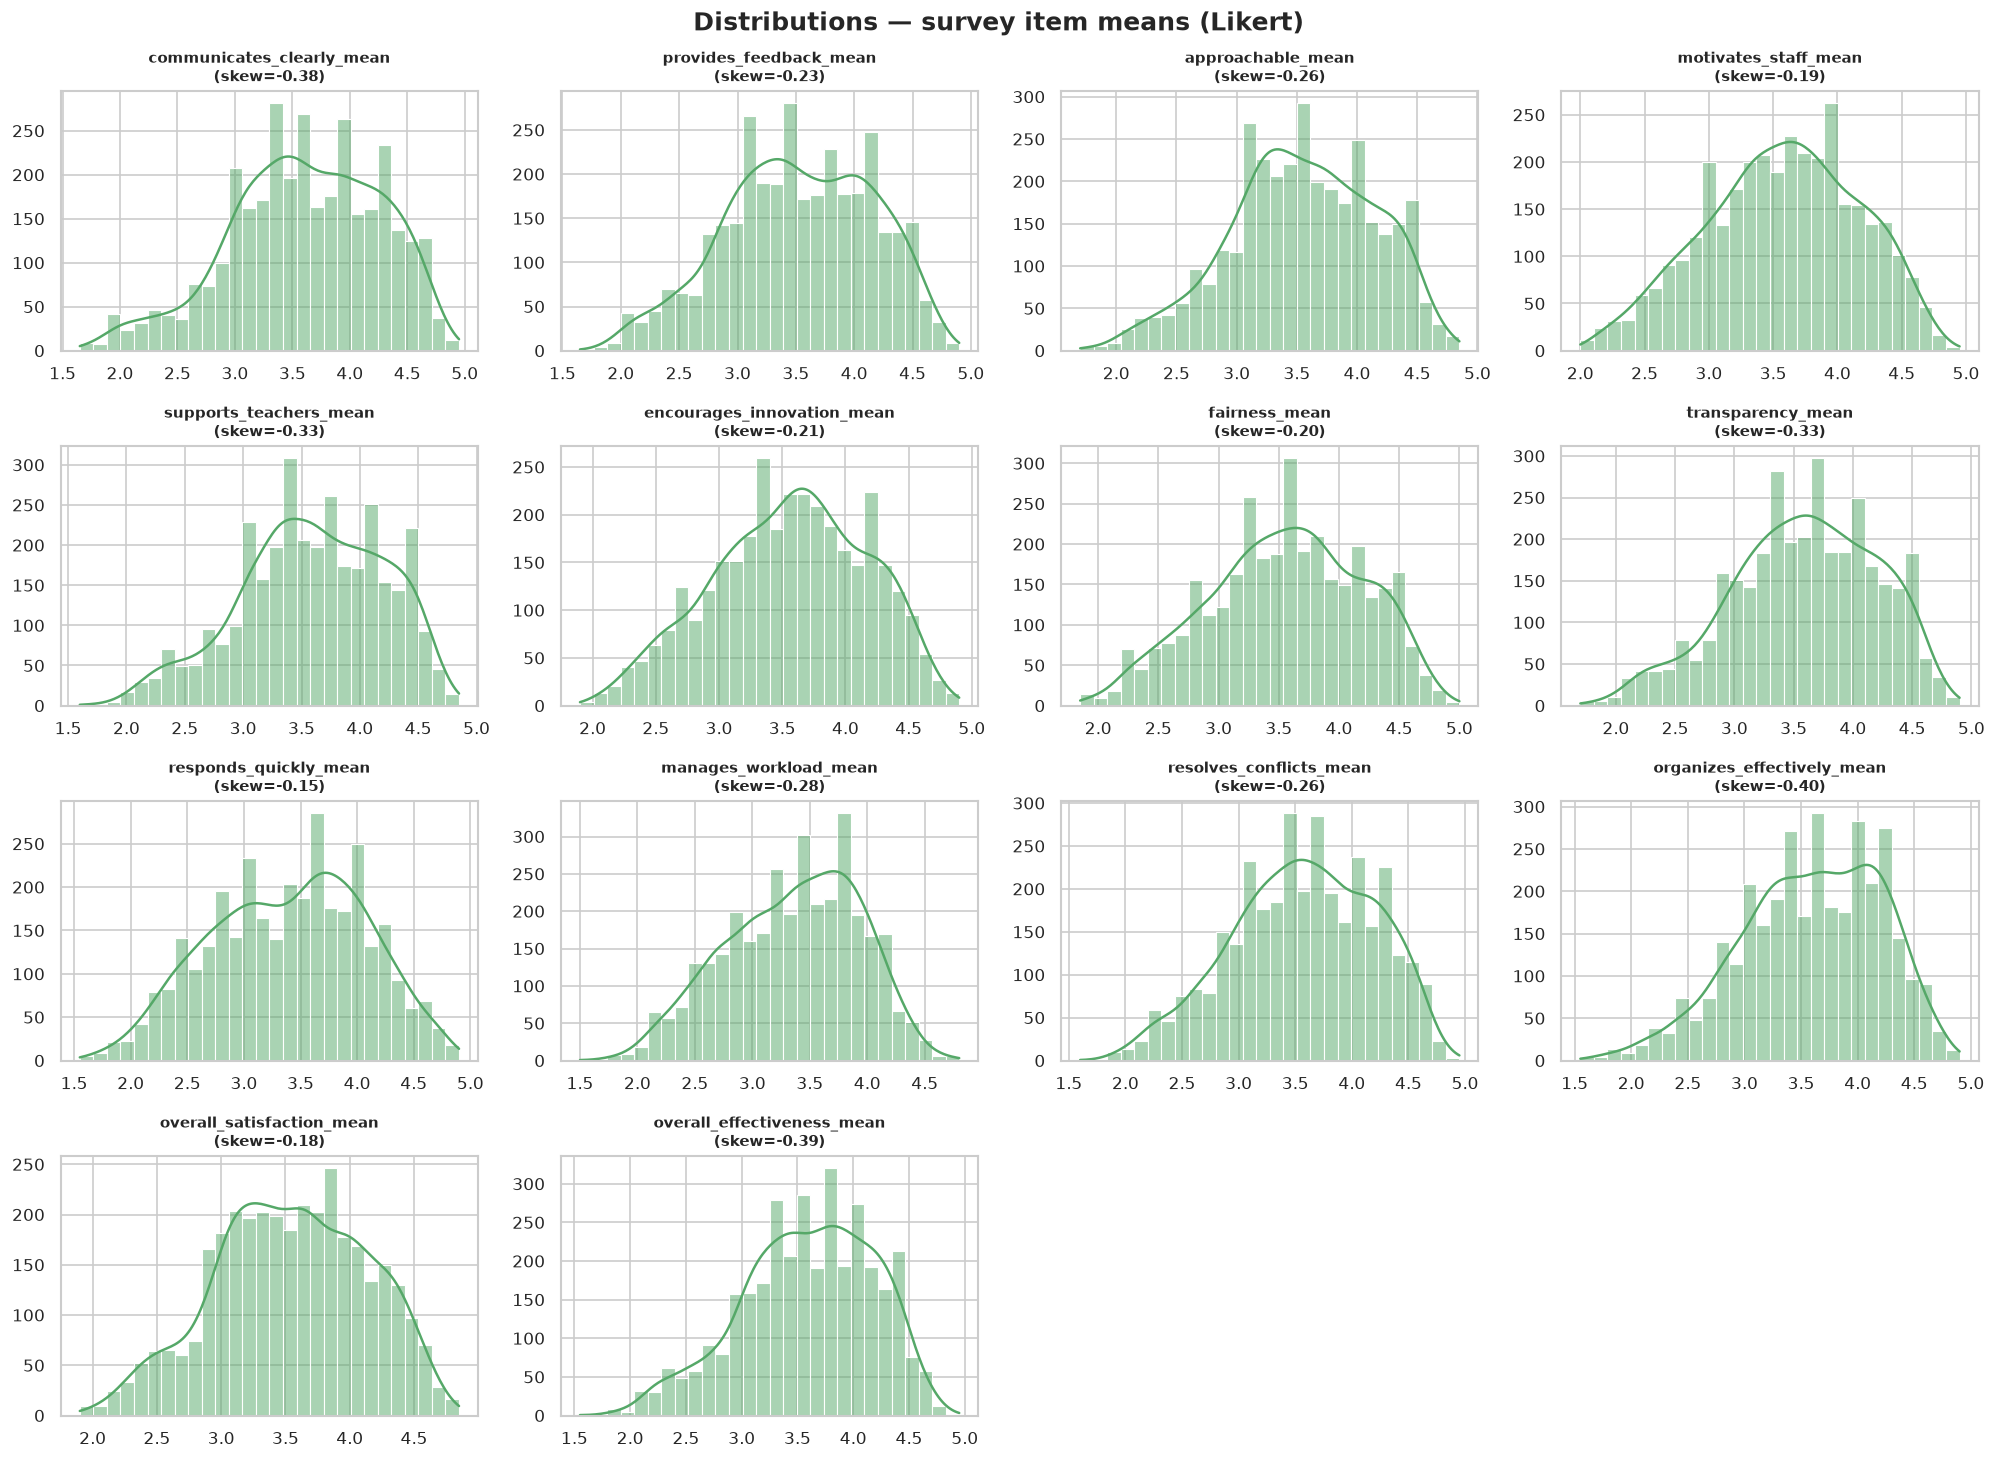

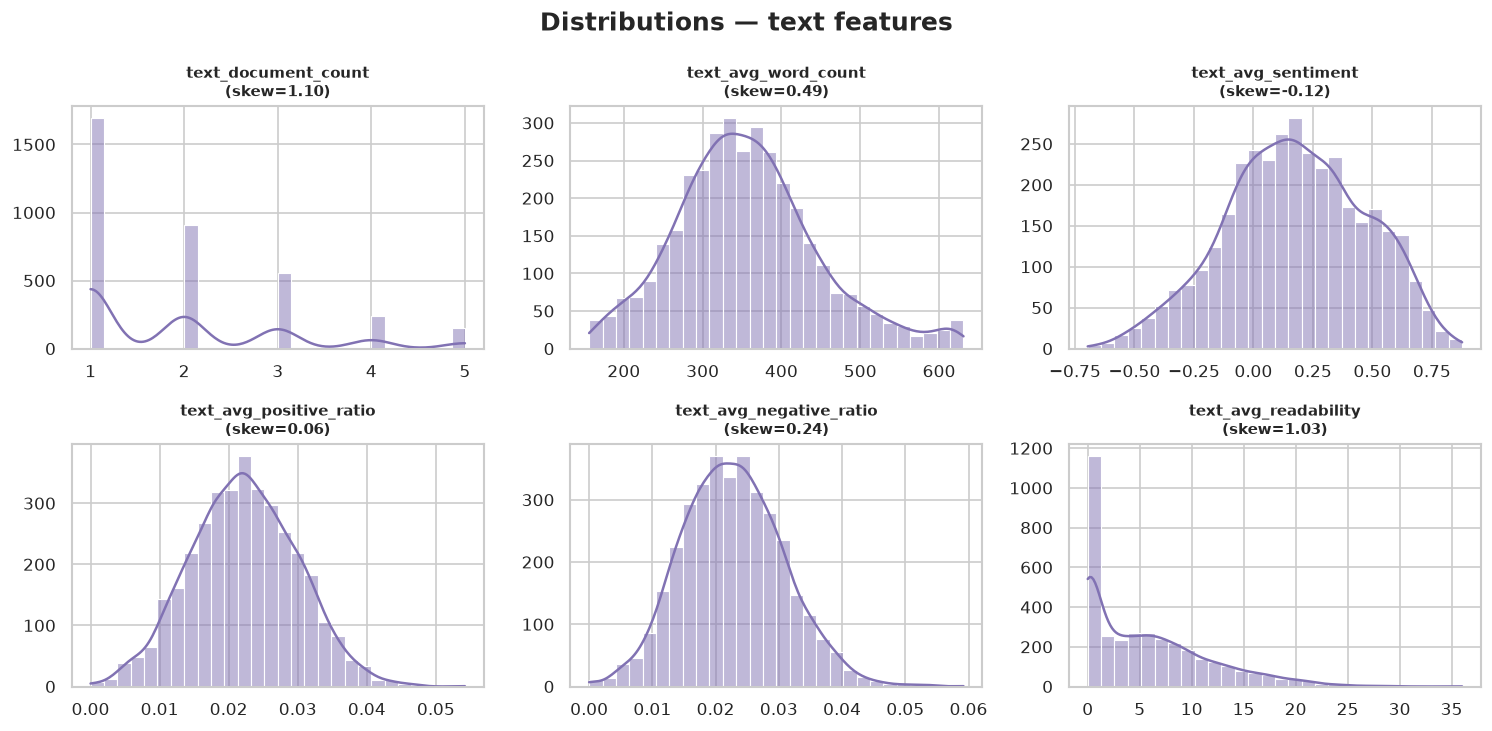


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Label scores are broadly bell-shaped (they aggregate many latent influences), whereas administrative
  counts and latency variables are right-skewed — consistent with Poisson / Log-Normal generation and
  signalling that log or rank transforms will help linear models. Survey item means concentrate in the
  upper Likert range with left skew, the classic 'leniency' pattern of real teacher-rating instruments.
════════════════════════════════════════════════════════════════════════════════



In [8]:
distribution_grid(SURVEY_MEAN_COLS, "Distributions — survey item means (Likert)",
                  "section03_dist_survey", ncols=4, color=PALETTE[2])
distribution_grid(TEXT_NUM, "Distributions — text features",
                  "section03_dist_text", ncols=3, color=PALETTE[4])

skew_tbl = df[NUMERIC_COLS].apply(lambda s: stats.skew(s.dropna())).sort_values()
savetable(skew_tbl.rename("skewness").to_frame(), "section03_skewness")
insight("""
Label scores are broadly bell-shaped (they aggregate many latent influences), whereas administrative
counts and latency variables are right-skewed — consistent with Poisson / Log-Normal generation and
signalling that log or rank transforms will help linear models. Survey item means concentrate in the
upper Likert range with left skew, the classic 'leniency' pattern of real teacher-rating instruments.
""")

# 4 — Univariate Analysis: Categorical Features

Frequency analysis of the categorical fields: the behavioural target, demographic attributes and the
dominant text descriptors. These counts reveal class balance and the composition of the administrator
population and their communication.

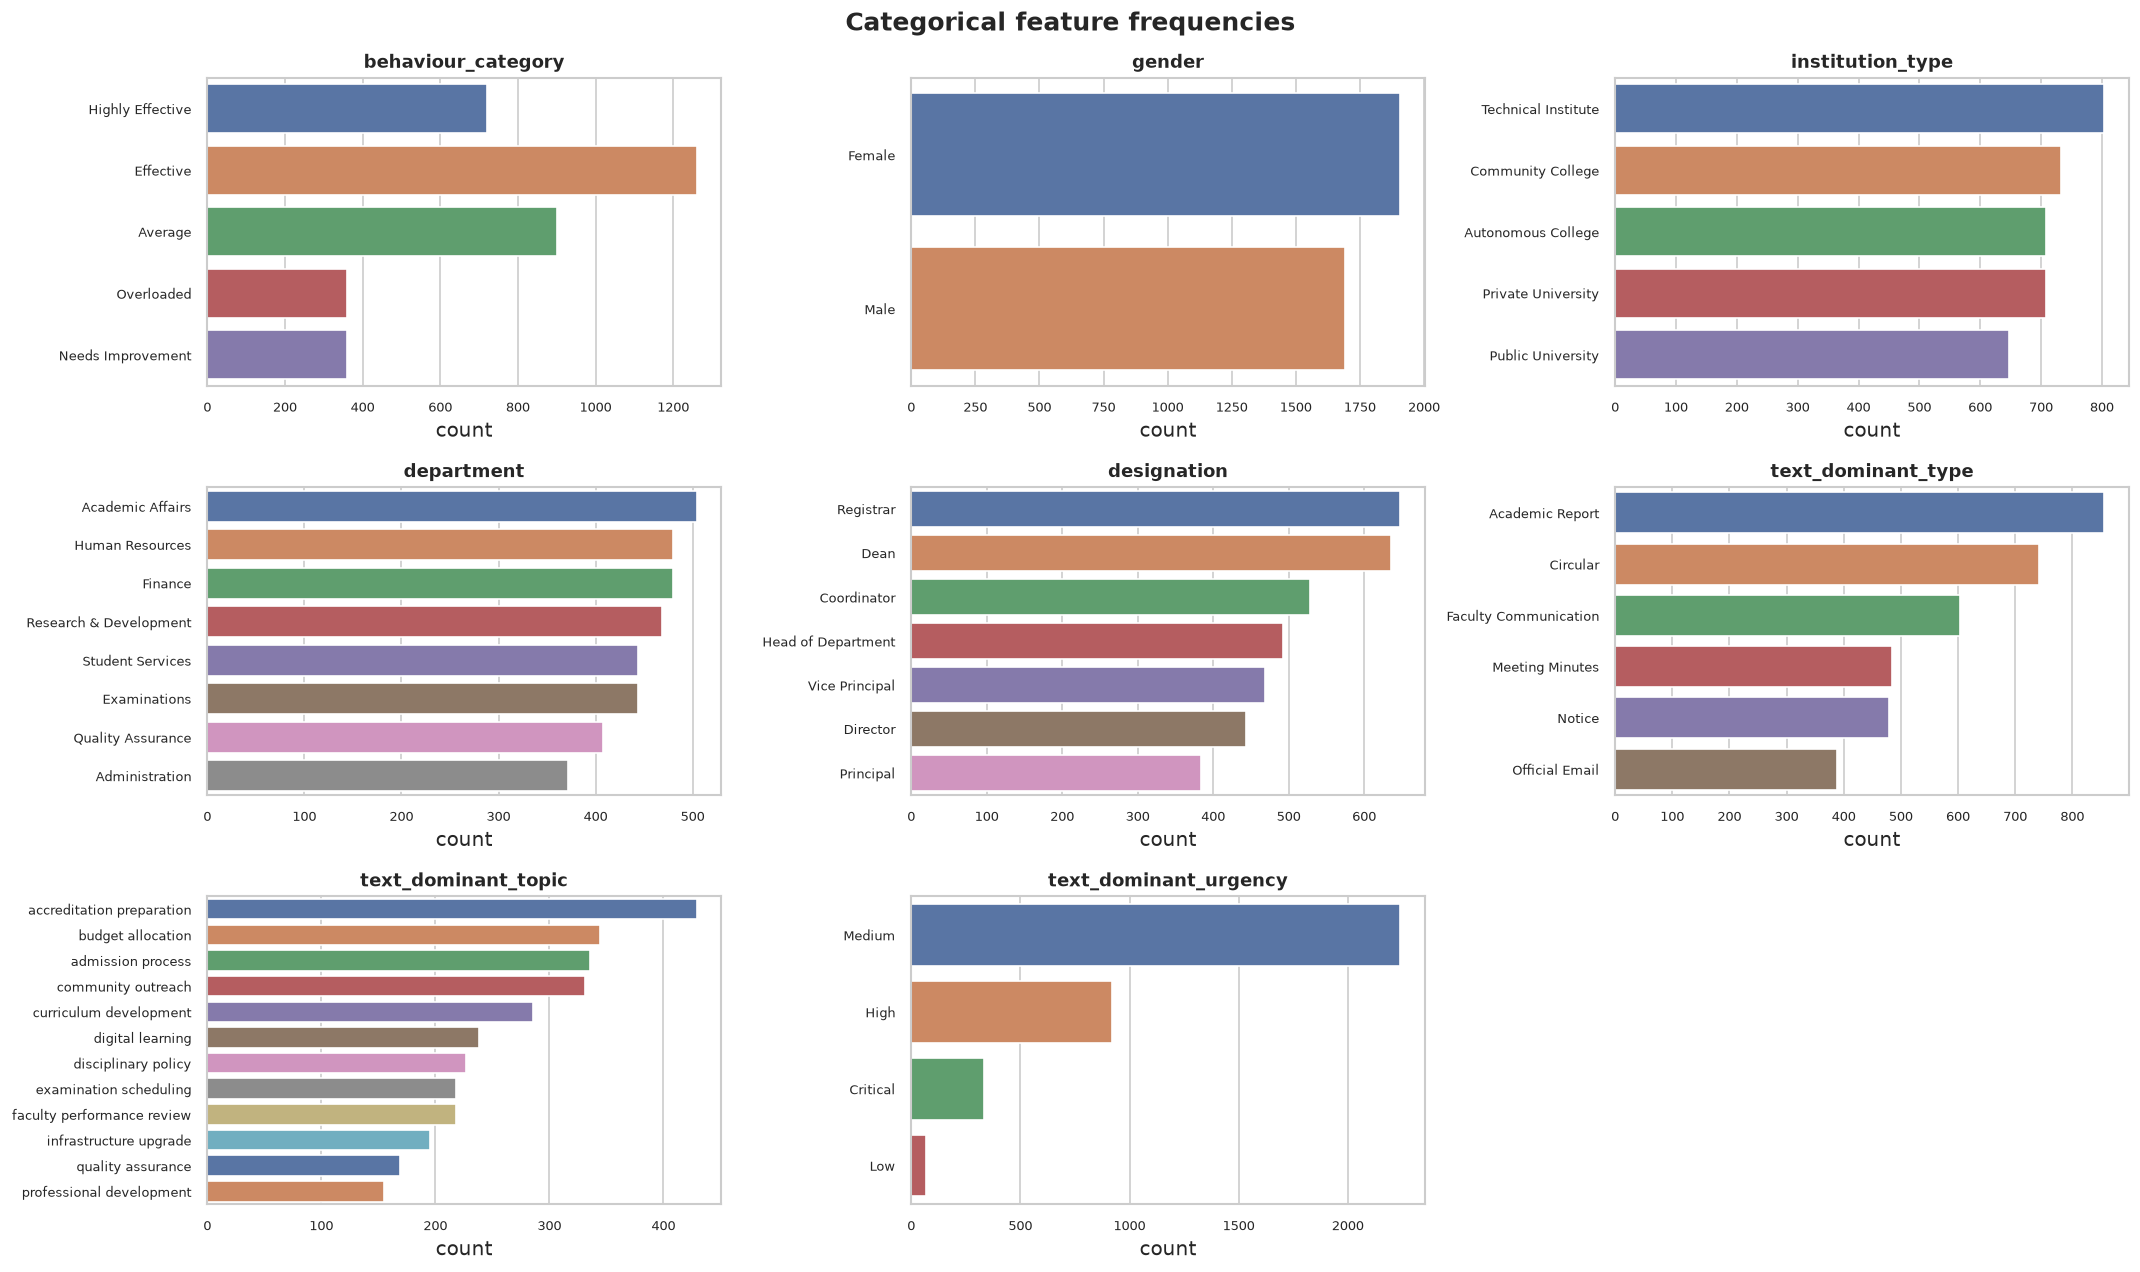


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  The behaviour target shows the intended imbalance (Effective largest, Overloaded / Needs-Improvement
  smallest). Demographics are broadly uniform across gender, institution type, department and
  designation — the population is diverse and not confounded by any single attribute — while dominant
  communication types and topics are well spread across the educational-administration domain.
════════════════════════════════════════════════════════════════════════════════



In [9]:
cat_cols = [CATEGORY_COL] + DEMOGRAPHICS + \
           [c for c in ["text_dominant_type", "text_dominant_topic", "text_dominant_urgency"] if c in df.columns]
cat_cols = [c for c in cat_cols if c != "age" and c != "years_experience"]

n = len(cat_cols); ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, cat_cols):
    vc = df[c].value_counts().head(12)
    order = CATEGORY_ORDER if c == CATEGORY_COL else vc.index
    sns.countplot(data=df, y=c, order=order, ax=ax, palette="deep")
    ax.set_title(c, fontsize=11); ax.set_xlabel("count"); ax.set_ylabel("")
    ax.tick_params(labelsize=8)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("Categorical feature frequencies", fontsize=15, fontweight="bold")
save_fig(fig, "section04_categoricals"); plt.show()

insight("""
The behaviour target shows the intended imbalance (Effective largest, Overloaded / Needs-Improvement
smallest). Demographics are broadly uniform across gender, institution type, department and
designation — the population is diverse and not confounded by any single attribute — while dominant
communication types and topics are well spread across the educational-administration domain.
""")

# 5 — Behavioural Labels: Deep Dive

The five continuous scores and the categorical behaviour label are the modelling targets. We study
their marginal distributions, mutual relationships, and — crucially — how the continuous scores
differ across behaviour categories, which reveals the semantic meaning of each category.

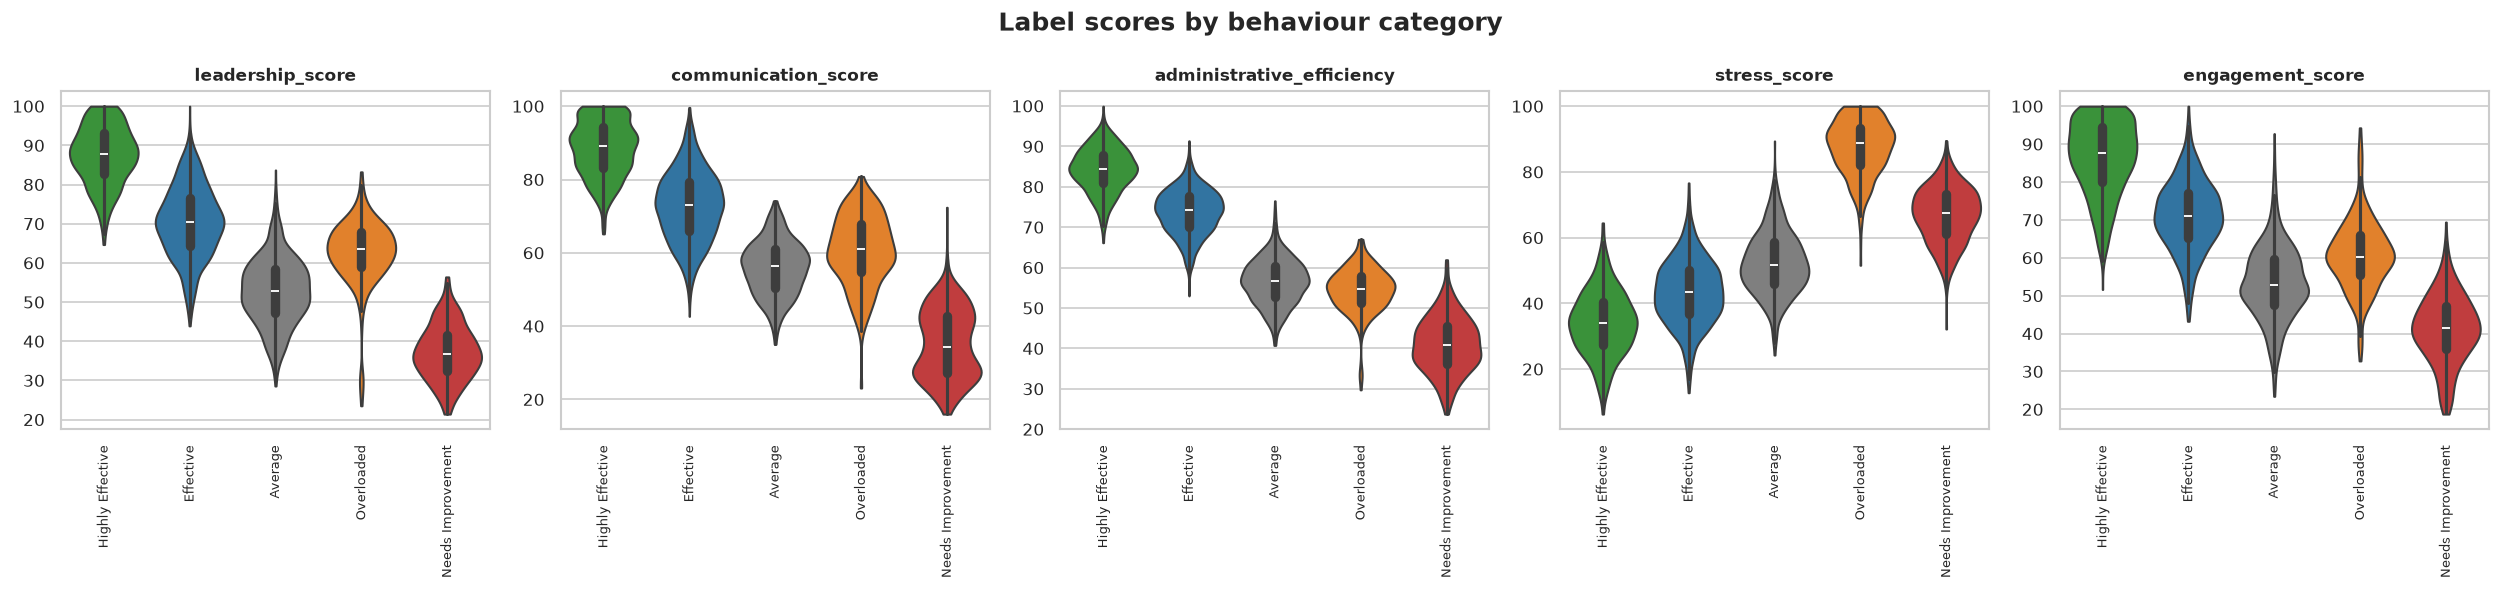

,leadership_score,communication_score,administrative_efficiency,stress_score,engagement_score
behaviour_category,,,,,
Highly Effective,87.5,88.5,84.2,34.0,86.3
Effective,70.4,72.7,73.8,43.4,71.1
Average,52.7,55.9,56.5,52.3,53.4
Overloaded,62.6,60.7,54.5,87.5,60.8
Needs Improvement,37.2,35.0,40.9,66.9,41.2


In [10]:
# Score distributions by category (violin + box).
fig, axes = plt.subplots(1, len(LABEL_SCORES), figsize=(4.2 * len(LABEL_SCORES), 5), sharey=False)
for ax, score in zip(axes, LABEL_SCORES):
    sns.violinplot(data=df, x=CATEGORY_COL, y=score, order=CATEGORY_ORDER,
                   palette=CATEGORY_COLORS, ax=ax, cut=0)
    ax.set_title(score, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=90, labelsize=8)
fig.suptitle("Label scores by behaviour category", fontsize=15, fontweight="bold")
save_fig(fig, "section05_scores_by_category"); plt.show()

# Mean score profile per category.
profile = df.groupby(CATEGORY_COL)[LABEL_SCORES].mean().reindex(CATEGORY_ORDER).round(1)
savetable(profile, "section05_score_profile")
display(profile)

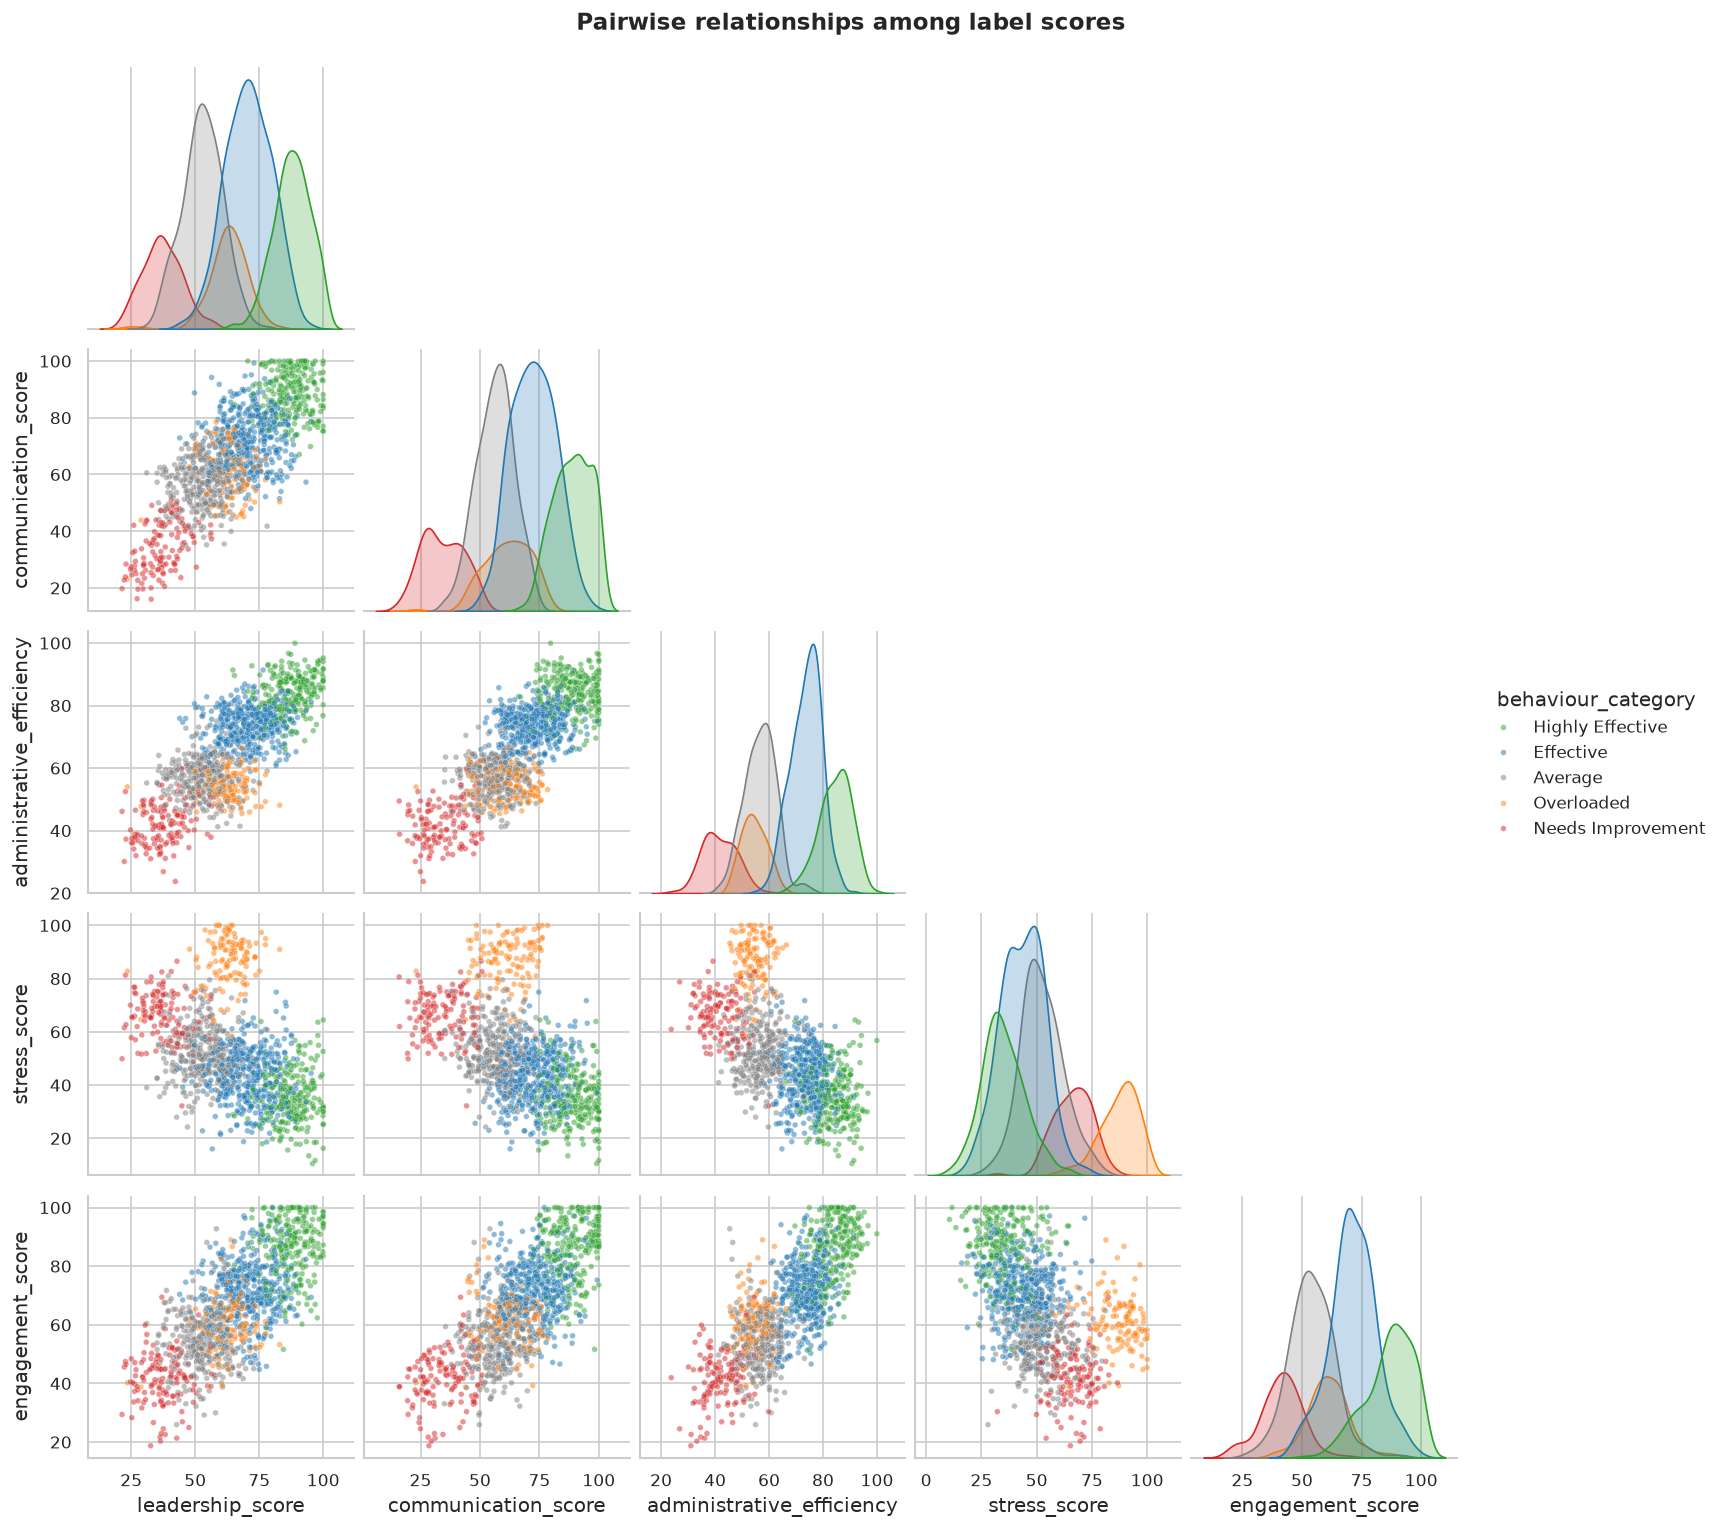


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Leadership, communication, efficiency and engagement scores move together (all positively correlated)
  and rise monotonically from Needs-Improvement to Highly-Effective, confirming the category ordering.
  Stress score behaves distinctly — it peaks for the Overloaded group even though their competence
  scores remain moderate, which is exactly the intended signature that separates 'Overloaded' from
  'Needs Improvement'.
════════════════════════════════════════════════════════════════════════════════



In [11]:
# Pairwise relationships among the scores.
g = sns.pairplot(df[LABEL_SCORES + [CATEGORY_COL]].dropna().sample(min(1200, len(df)), random_state=42),
                 hue=CATEGORY_COL, palette=CATEGORY_COLORS, corner=True,
                 plot_kws={"s": 12, "alpha": 0.5})
g.fig.suptitle("Pairwise relationships among label scores", y=1.02, fontsize=14, fontweight="bold")
g.savefig(FIG_DIR / "section05_score_pairplot.png", bbox_inches="tight"); plt.show()

score_corr = df[LABEL_SCORES].corr()
savetable(score_corr, "section05_score_correlation")
insight(f"""
Leadership, communication, efficiency and engagement scores move together (all positively correlated)
and rise monotonically from Needs-Improvement to Highly-Effective, confirming the category ordering.
Stress score behaves distinctly — it peaks for the Overloaded group even though their competence
scores remain moderate, which is exactly the intended signature that separates 'Overloaded' from
'Needs Improvement'.
""")

# 6 — Correlation & Bivariate Relationships

We map the full numeric correlation structure and then zoom into the theoretically important
bivariate relationships that connect the modalities, fitting regression lines to visualise their
strength and direction.

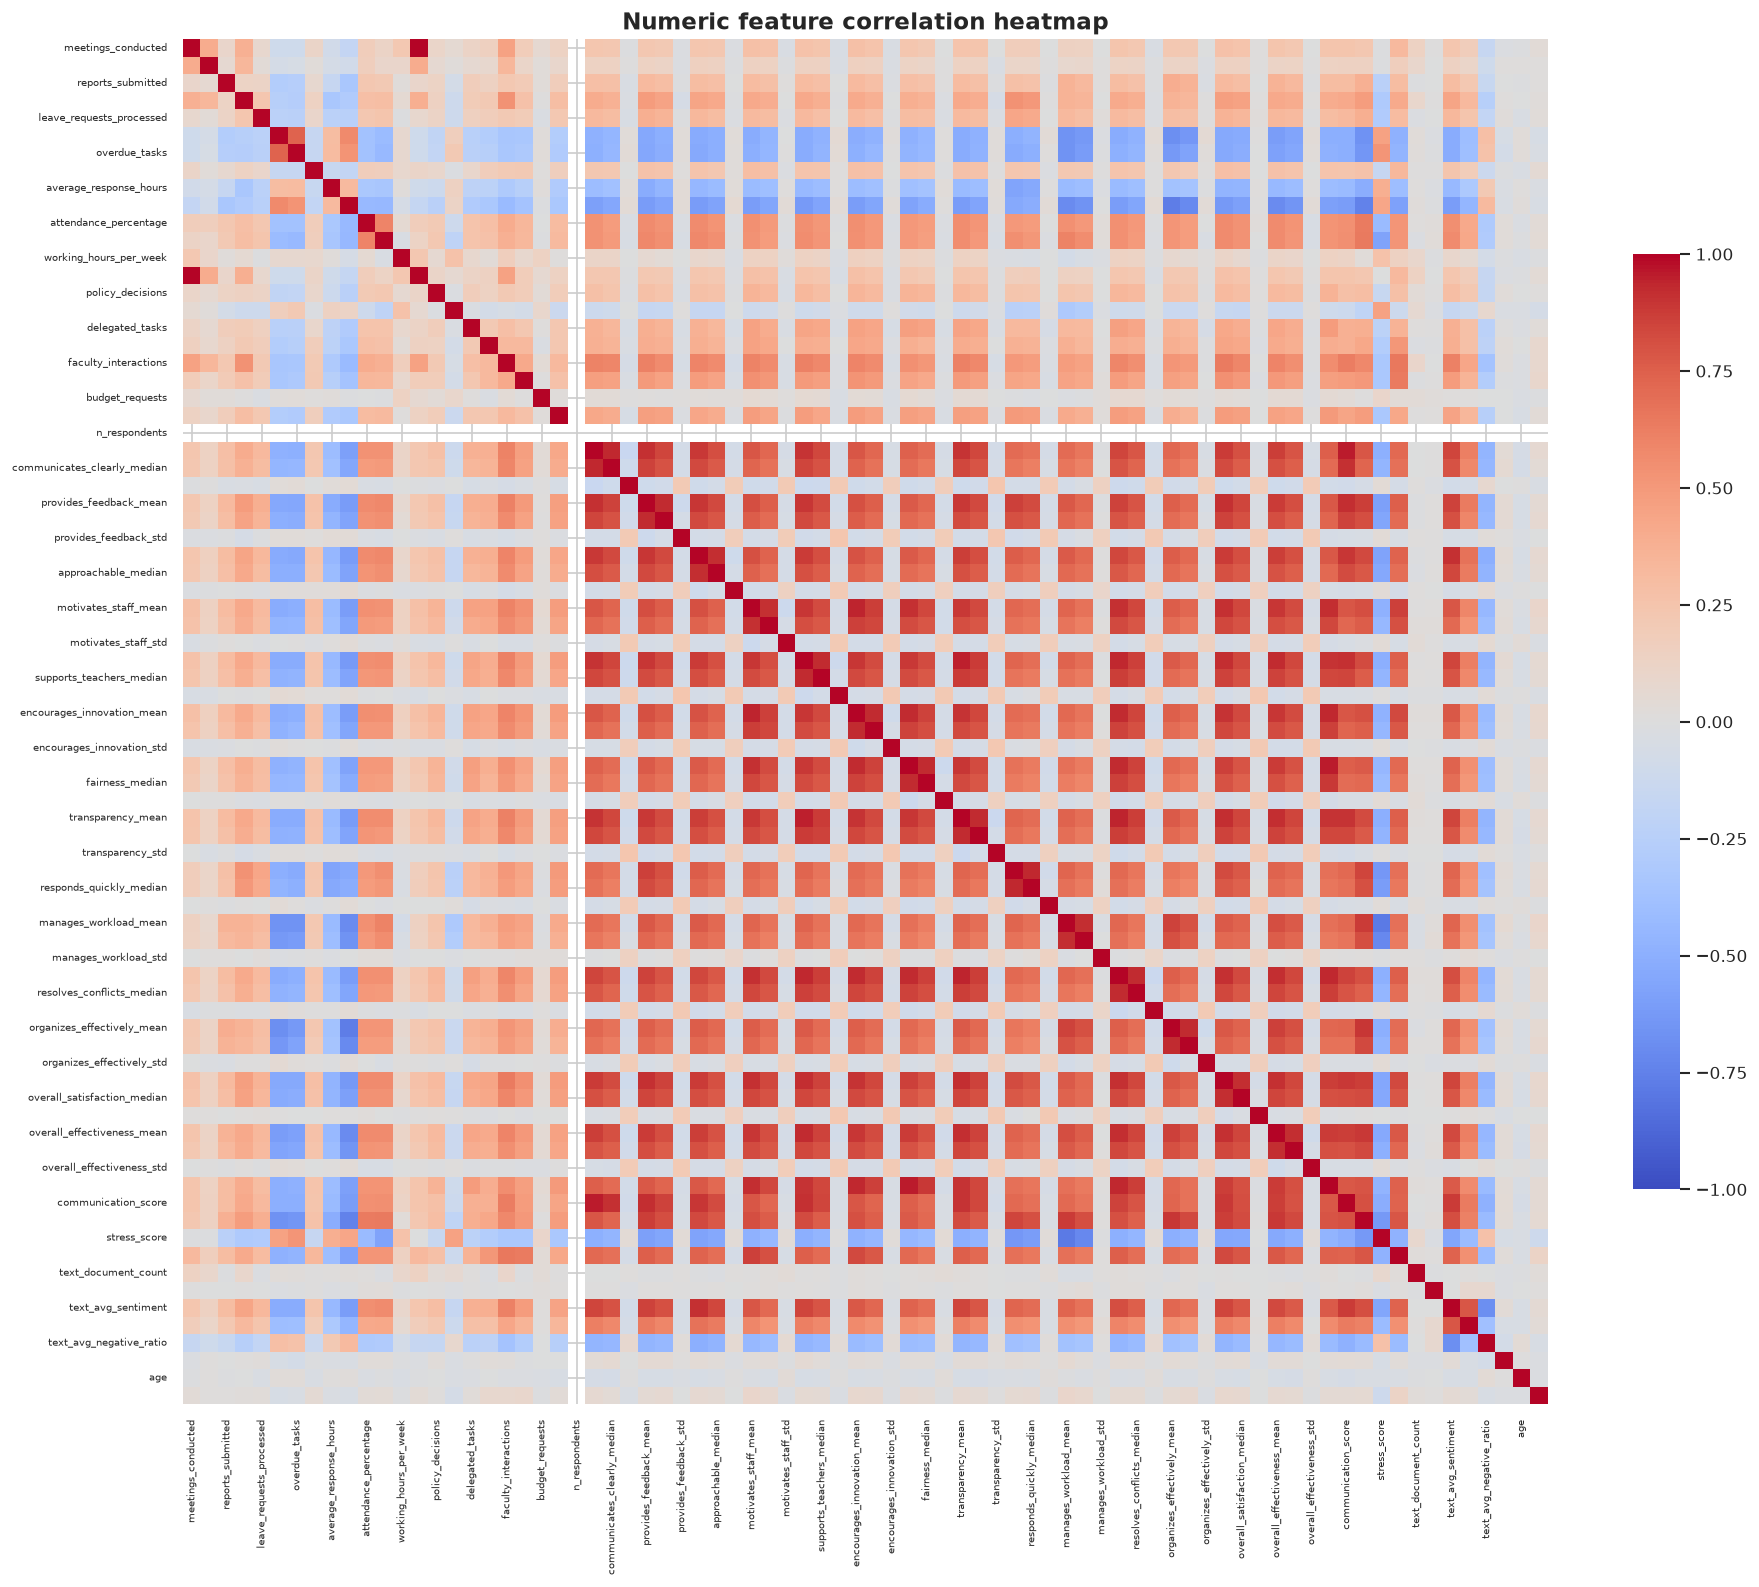

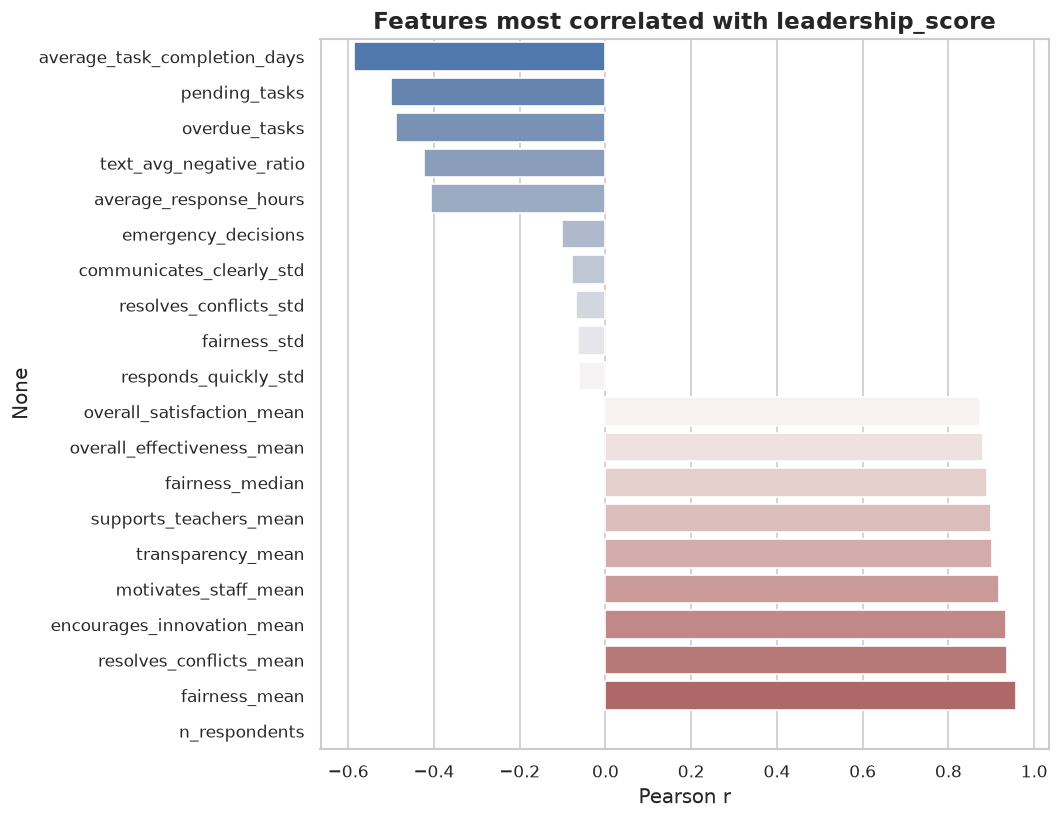

In [12]:
corr = df[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Numeric feature correlation heatmap"); ax.tick_params(labelsize=6)
save_fig(fig, "section06_corr_heatmap"); plt.show()

# Features most correlated with leadership_score.
lead_corr = corr["leadership_score"].drop(LABEL_SCORES, errors="ignore").sort_values()
top = pd.concat([lead_corr.head(10), lead_corr.tail(10)])
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top.values, y=top.index, ax=ax, palette="vlag")
ax.set_title("Features most correlated with leadership_score"); ax.set_xlabel("Pearson r")
save_fig(fig, "section06_leadership_drivers"); plt.show()

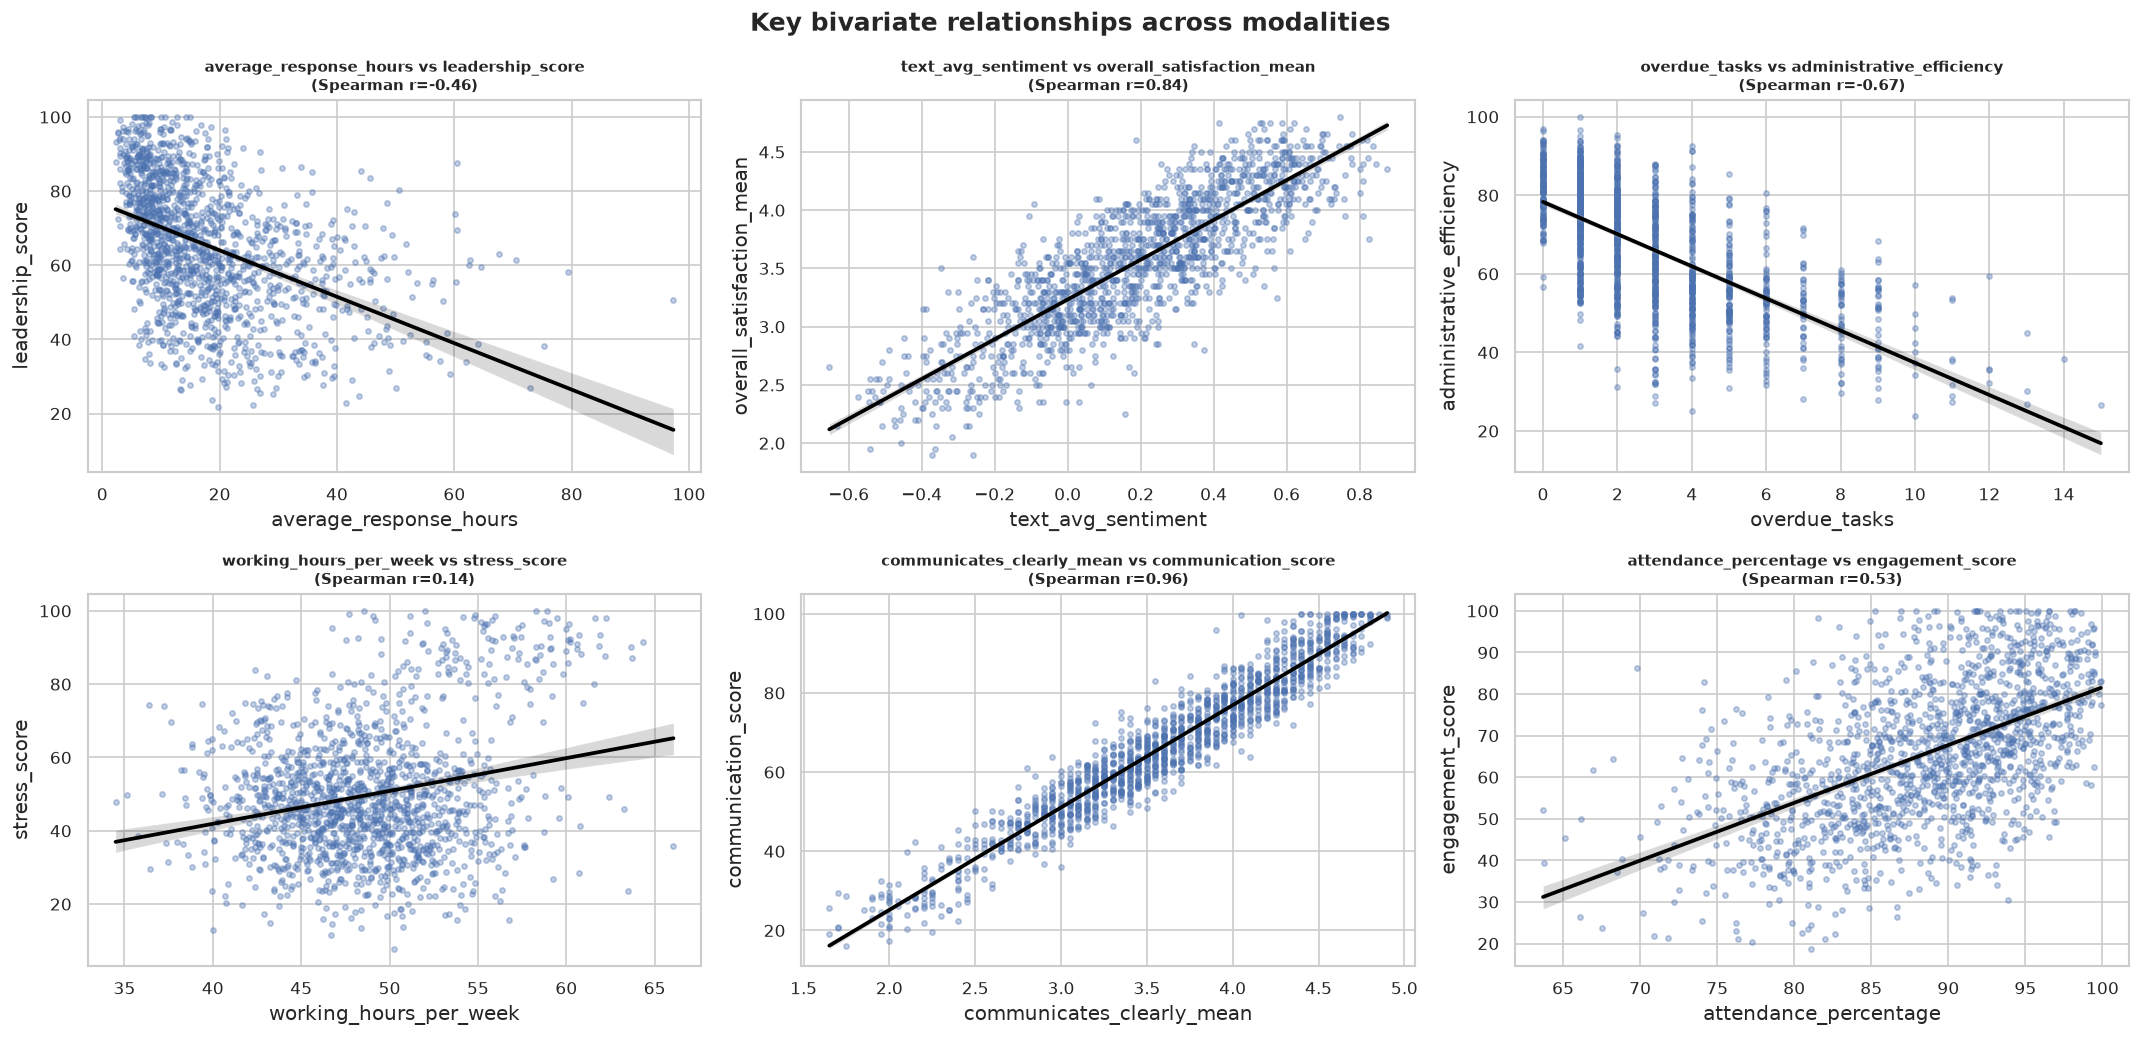


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  The scatter panels make the cross-modal logic tangible: faster responses and higher attendance track
  higher leadership/engagement; positive text sentiment tracks higher teacher satisfaction; heavier
  weekly hours track higher stress; and overdue tasks depress efficiency. These monotone relationships
  are the exploitable signal for multimodal fusion.
════════════════════════════════════════════════════════════════════════════════



In [13]:
PAIRS = [
    ("average_response_hours", "leadership_score"),
    ("text_avg_sentiment", "overall_satisfaction_mean"),
    ("overdue_tasks", "administrative_efficiency"),
    ("working_hours_per_week", "stress_score"),
    ("communicates_clearly_mean", "communication_score"),
    ("attendance_percentage", "engagement_score"),
]
PAIRS = [(a, b) for a, b in PAIRS if a in df.columns and b in df.columns]
ncols = 3; nrows = int(np.ceil(len(PAIRS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.4 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (a, b) in zip(axes, PAIRS):
    sub = df[[a, b]].dropna().sample(min(1500, df[[a, b]].dropna().shape[0]), random_state=42)
    sns.regplot(data=sub, x=a, y=b, ax=ax, scatter_kws={"s": 10, "alpha": 0.35},
                line_kws={"color": "black"})
    r = stats.spearmanr(df[a], df[b], nan_policy="omit").statistic
    ax.set_title(f"{a} vs {b}\n(Spearman r={r:.2f})", fontsize=9)
for ax in axes[len(PAIRS):]:
    ax.axis("off")
fig.suptitle("Key bivariate relationships across modalities", fontsize=15, fontweight="bold")
save_fig(fig, "section06_bivariate"); plt.show()
insight("""
The scatter panels make the cross-modal logic tangible: faster responses and higher attendance track
higher leadership/engagement; positive text sentiment tracks higher teacher satisfaction; heavier
weekly hours track higher stress; and overdue tasks depress efficiency. These monotone relationships
are the exploitable signal for multimodal fusion.
""")

# 7 — Behaviour-Category Profiling

To characterise *what makes each category distinct*, we standardise every numeric feature and compare
category means (z-scores). A heatmap exposes the multivariate signature of each profile, and a radar
chart contrasts their survey perceptions.

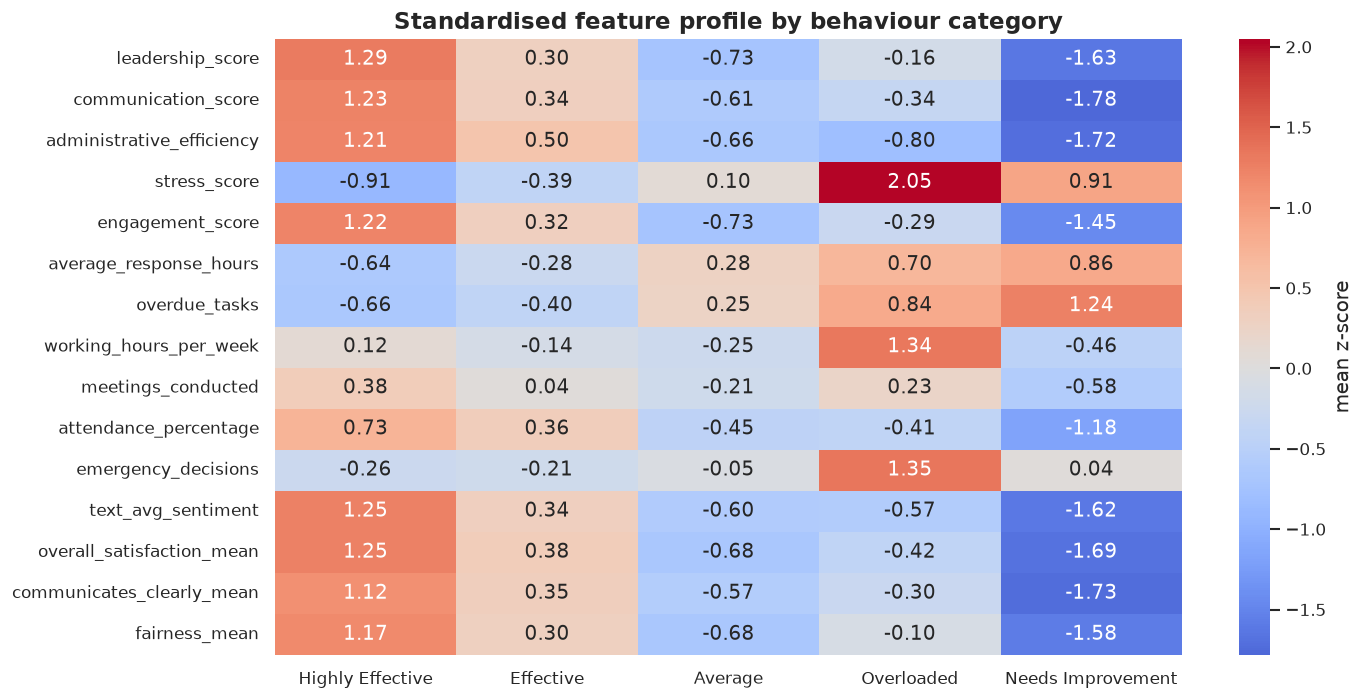

PosixPath('output/eda/tables/section07_category_zprofile.csv')

In [14]:
prof_features = LABEL_SCORES + [c for c in [
    "average_response_hours", "overdue_tasks", "working_hours_per_week", "meetings_conducted",
    "attendance_percentage", "emergency_decisions", "text_avg_sentiment",
    "overall_satisfaction_mean", "communicates_clearly_mean", "fairness_mean"] if c in df.columns]
z = df.copy()
z[prof_features] = StandardScaler().fit_transform(df[prof_features].fillna(df[prof_features].median()))
cat_z = z.groupby(CATEGORY_COL)[prof_features].mean().reindex(CATEGORY_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cat_z.T, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "mean z-score"}, ax=ax)
ax.set_title("Standardised feature profile by behaviour category")
ax.set_xlabel(""); ax.set_ylabel("")
save_fig(fig, "section07_category_heatmap"); plt.show()
savetable(cat_z.round(3), "section07_category_zprofile")

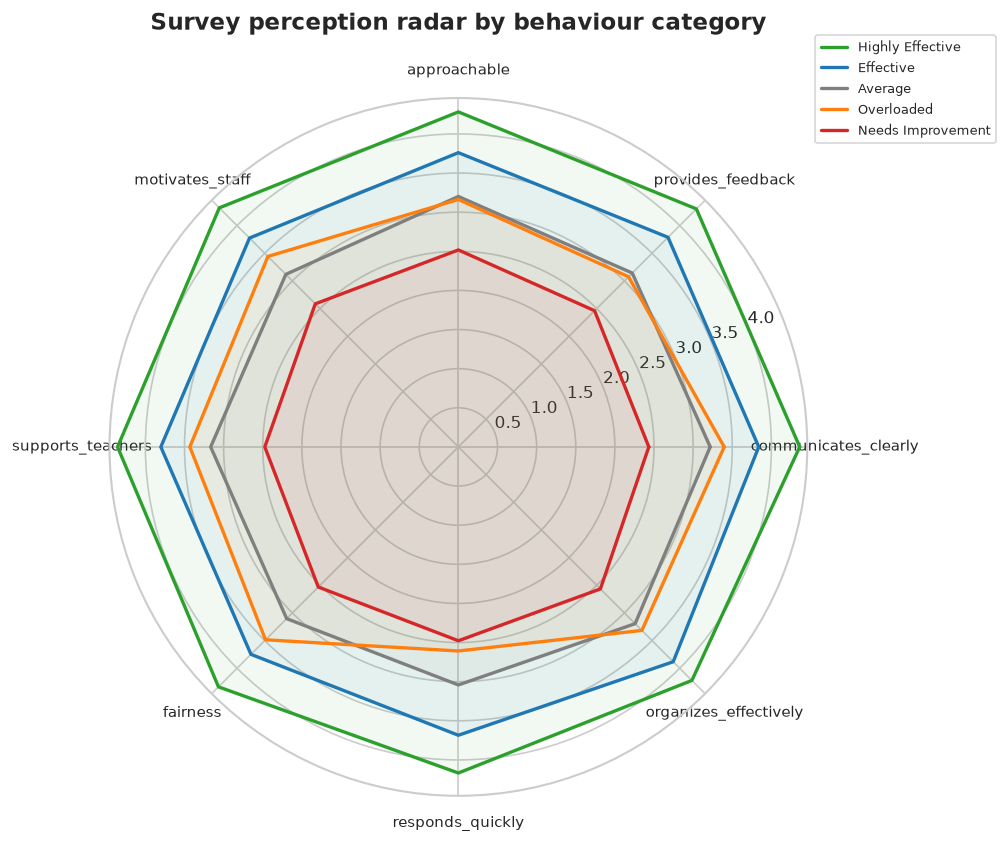


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Each category has a coherent multivariate fingerprint: Highly-Effective administrators sit far above
  average on every competence dimension with low stress/overdue tasks; the Overloaded profile is marked
  by strongly positive workload/hours/stress z-scores despite mid-range competence; Needs-Improvement is
  uniformly below average. The radar confirms the survey construct discriminates cleanly between groups.
════════════════════════════════════════════════════════════════════════════════



In [15]:
# Radar chart of survey-item means per category.
radar_items = [c for c in ["communicates_clearly_mean", "provides_feedback_mean", "approachable_mean",
               "motivates_staff_mean", "supports_teachers_mean", "fairness_mean",
               "responds_quickly_mean", "organizes_effectively_mean"] if c in df.columns]
radar = df.groupby(CATEGORY_COL)[radar_items].mean().reindex(CATEGORY_ORDER)
labels = [c.replace("_mean", "") for c in radar_items]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw=dict(polar=True))
for cat in CATEGORY_ORDER:
    vals = radar.loc[cat].tolist(); vals += vals[:1]
    ax.plot(angles, vals, label=cat, color=CATEGORY_COLORS[cat], linewidth=2)
    ax.fill(angles, vals, color=CATEGORY_COLORS[cat], alpha=0.06)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_title("Survey perception radar by behaviour category", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1), fontsize=8)
save_fig(fig, "section07_radar"); plt.show()
insight("""
Each category has a coherent multivariate fingerprint: Highly-Effective administrators sit far above
average on every competence dimension with low stress/overdue tasks; the Overloaded profile is marked
by strongly positive workload/hours/stress z-scores despite mid-range competence; Needs-Improvement is
uniformly below average. The radar confirms the survey construct discriminates cleanly between groups.
""")

# 8 — Demographic Analysis

Do behavioural outcomes vary with administrator demographics? We compare label scores across gender,
institution type, department and designation, and explore how experience and age relate to
performance. In a well-designed synthetic dataset demographics should be largely *non-predictive*
(avoiding embedded bias), which we verify here.

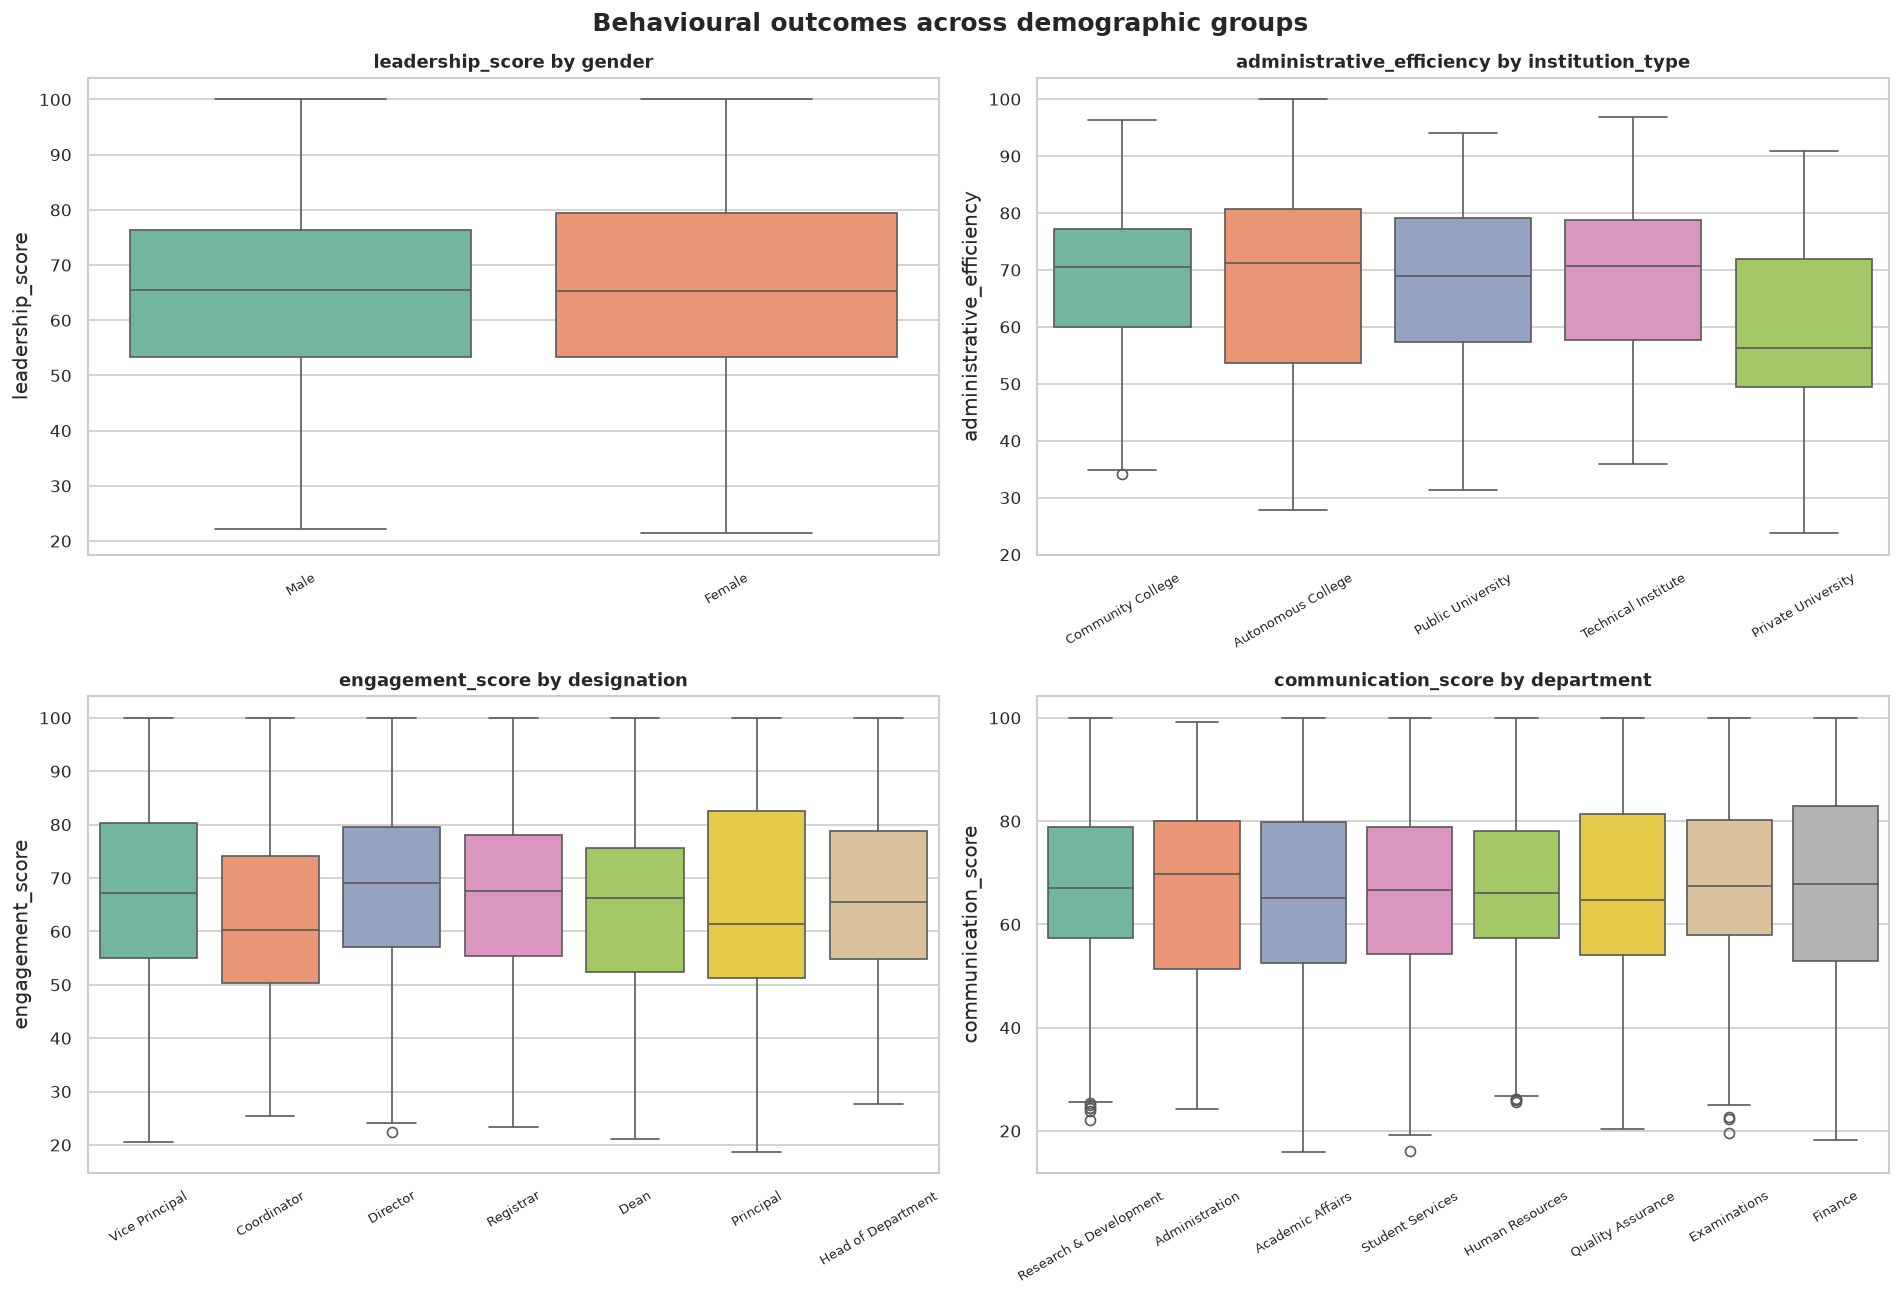

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
demo_plot = [("gender", "leadership_score"), ("institution_type", "administrative_efficiency"),
             ("designation", "engagement_score"), ("department", "communication_score")]
for ax, (d, score) in zip(axes.ravel(), demo_plot):
    if d in df.columns:
        sns.boxplot(data=df, x=d, y=score, ax=ax, palette="Set2")
        ax.set_title(f"{score} by {d}", fontsize=11)
        ax.tick_params(axis="x", labelrotation=30, labelsize=8); ax.set_xlabel("")
fig.suptitle("Behavioural outcomes across demographic groups", fontsize=15, fontweight="bold")
save_fig(fig, "section08_demographics"); plt.show()

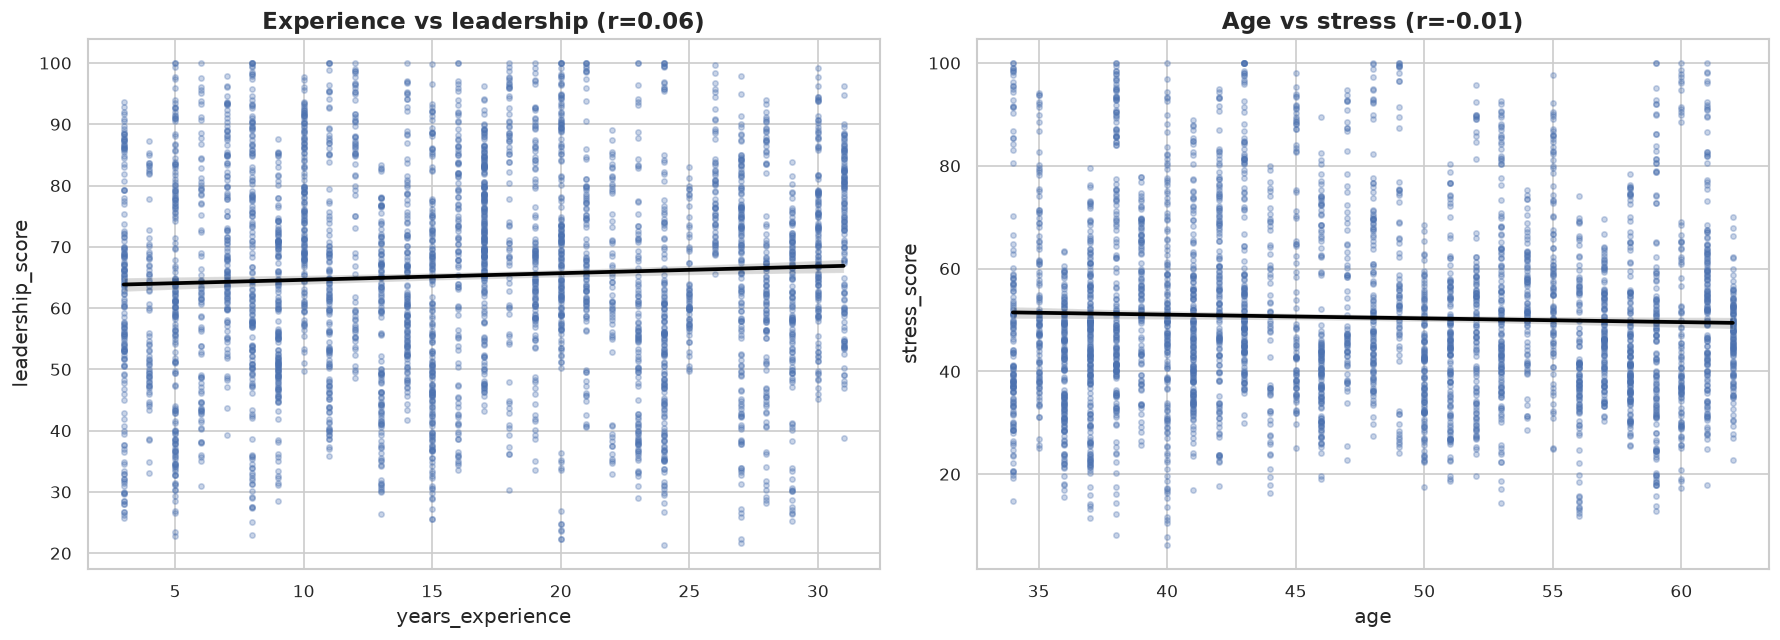

,demographic,score,eta_squared
7,institution_type,administrative_efficiency,0.0556
5,institution_type,leadership_score,0.0451
6,institution_type,communication_score,0.0369
18,designation,stress_score,0.0301
9,institution_type,engagement_score,0.0205
17,designation,administrative_efficiency,0.0198
15,designation,leadership_score,0.0145
19,designation,engagement_score,0.0142
8,institution_type,stress_score,0.0132
3,gender,stress_score,0.0113



════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Demographic effect sizes are negligible (max eta^2 = 0.056, i.e. under 5.6% of
  variance explained), and experience/age show only weak associations with outcomes. Behaviour is
  therefore driven by the modality signals rather than by protected demographic attributes — a
  desirable, bias-aware property for downstream modelling.
════════════════════════════════════════════════════════════════════════════════



In [17]:
# Experience & age vs performance.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
if "years_experience" in df.columns:
    sns.regplot(data=df, x="years_experience", y="leadership_score", ax=axes[0],
                scatter_kws={"s": 10, "alpha": 0.3}, line_kws={"color": "black"})
    r = stats.spearmanr(df["years_experience"], df["leadership_score"]).statistic
    axes[0].set_title(f"Experience vs leadership (r={r:.2f})")
if "age" in df.columns:
    sns.regplot(data=df, x="age", y="stress_score", ax=axes[1],
                scatter_kws={"s": 10, "alpha": 0.3}, line_kws={"color": "black"})
    r = stats.spearmanr(df["age"], df["stress_score"]).statistic
    axes[1].set_title(f"Age vs stress (r={r:.2f})")
save_fig(fig, "section08_experience_age"); plt.show()

# Quantify demographic effect sizes (eta-squared via one-way ANOVA).
def eta_squared(groups):
    """One-way ANOVA effect size (eta^2) across a list of group arrays."""
    allv = np.concatenate(groups); grand = allv.mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_total = ((allv - grand) ** 2).sum()
    return ss_between / ss_total if ss_total else 0.0

rows = []
categorical_demos = [c for c in DEMOGRAPHICS if not pd.api.types.is_numeric_dtype(df[c])]
for d in categorical_demos:
    for score in LABEL_SCORES:
        groups = [g[score].dropna().values for _, g in df.groupby(d, observed=True)
                  if g[score].notna().sum() > 2]
        if len(groups) > 1:
            rows.append({"demographic": d, "score": score, "eta_squared": round(eta_squared(groups), 4)})
eta_df = pd.DataFrame(rows)
if not eta_df.empty:
    eta_df = eta_df.sort_values("eta_squared", ascending=False)
    savetable(eta_df, "section08_demographic_effect_sizes", index=False)
    display(eta_df.head(10))
    max_eta = float(eta_df["eta_squared"].max())
    insight(f"""
Demographic effect sizes are negligible (max eta^2 = {max_eta:.3f}, i.e. under {max_eta*100:.1f}% of
variance explained), and experience/age show only weak associations with outcomes. Behaviour is
therefore driven by the modality signals rather than by protected demographic attributes — a
desirable, bias-aware property for downstream modelling.
""")
else:
    print("No categorical demographic columns available for effect-size analysis.")

# 9 — Administrative-Log Exploration

The log modality captures operational behaviour. We explore workload composition, the relationship
between meetings conducted and attended, the task backlog (pending vs overdue), decision-making
volume and stakeholder interactions, and how these operational signals relate to stress and efficiency.

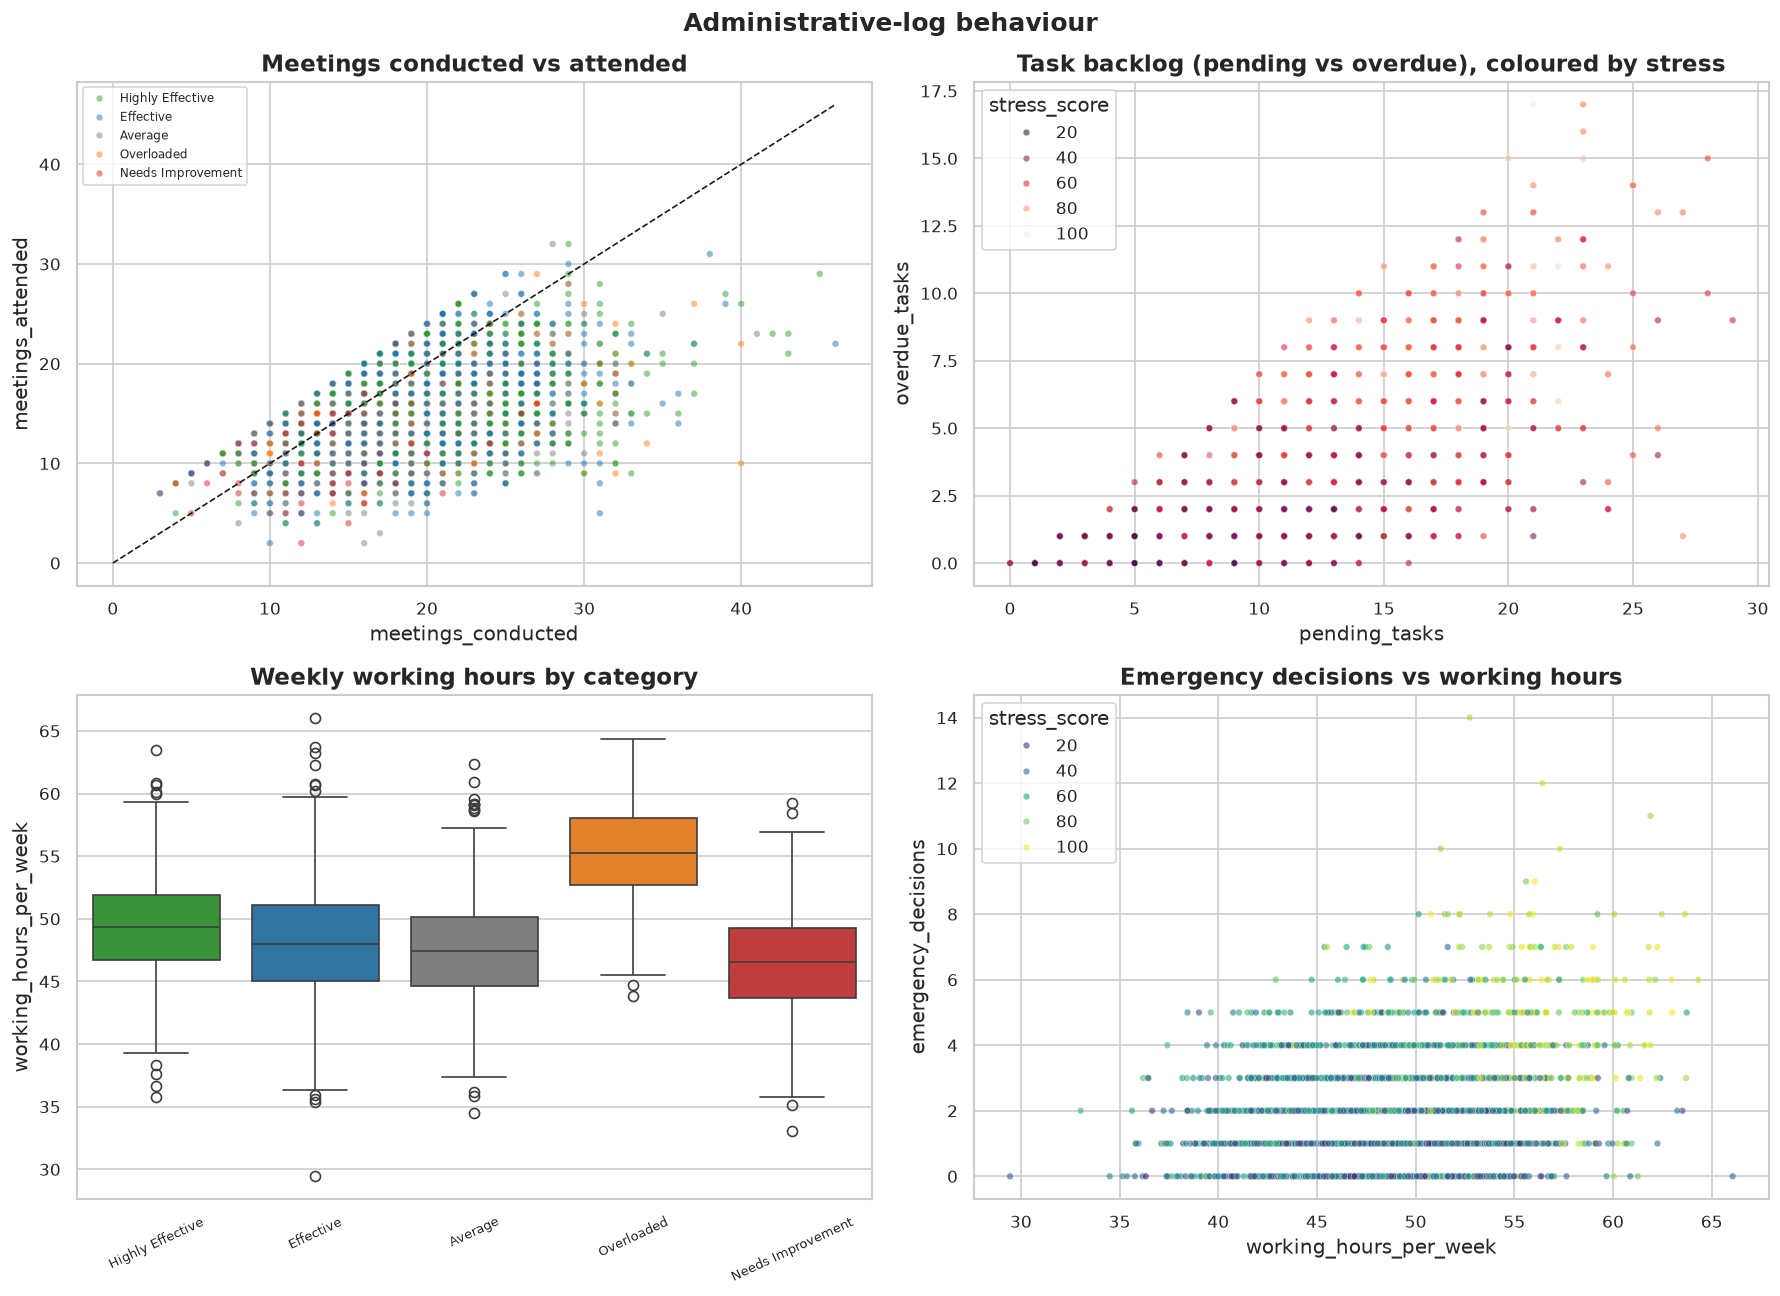

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Meetings conducted vs attended.
sns.scatterplot(data=df, x="meetings_conducted", y="meetings_attended", hue=CATEGORY_COL,
                palette=CATEGORY_COLORS, s=16, alpha=0.5, ax=axes[0, 0])
lim = df[["meetings_conducted", "meetings_attended"]].max().max()
axes[0, 0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0, 0].set_title("Meetings conducted vs attended"); axes[0, 0].legend(fontsize=7)

# Backlog: pending vs overdue.
sns.scatterplot(data=df, x="pending_tasks", y="overdue_tasks", hue="stress_score",
                palette="rocket", s=16, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Task backlog (pending vs overdue), coloured by stress")

# Working hours by category.
sns.boxplot(data=df, x=CATEGORY_COL, y="working_hours_per_week", order=CATEGORY_ORDER,
            palette=CATEGORY_COLORS, ax=axes[1, 0])
axes[1, 0].set_title("Weekly working hours by category")
axes[1, 0].tick_params(axis="x", labelrotation=25, labelsize=8); axes[1, 0].set_xlabel("")

# Emergency decisions vs workload.
sns.scatterplot(data=df, x="working_hours_per_week", y="emergency_decisions",
                hue="stress_score", palette="viridis", s=16, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Emergency decisions vs working hours")
fig.suptitle("Administrative-log behaviour", fontsize=15, fontweight="bold")
save_fig(fig, "section09_logs"); plt.show()

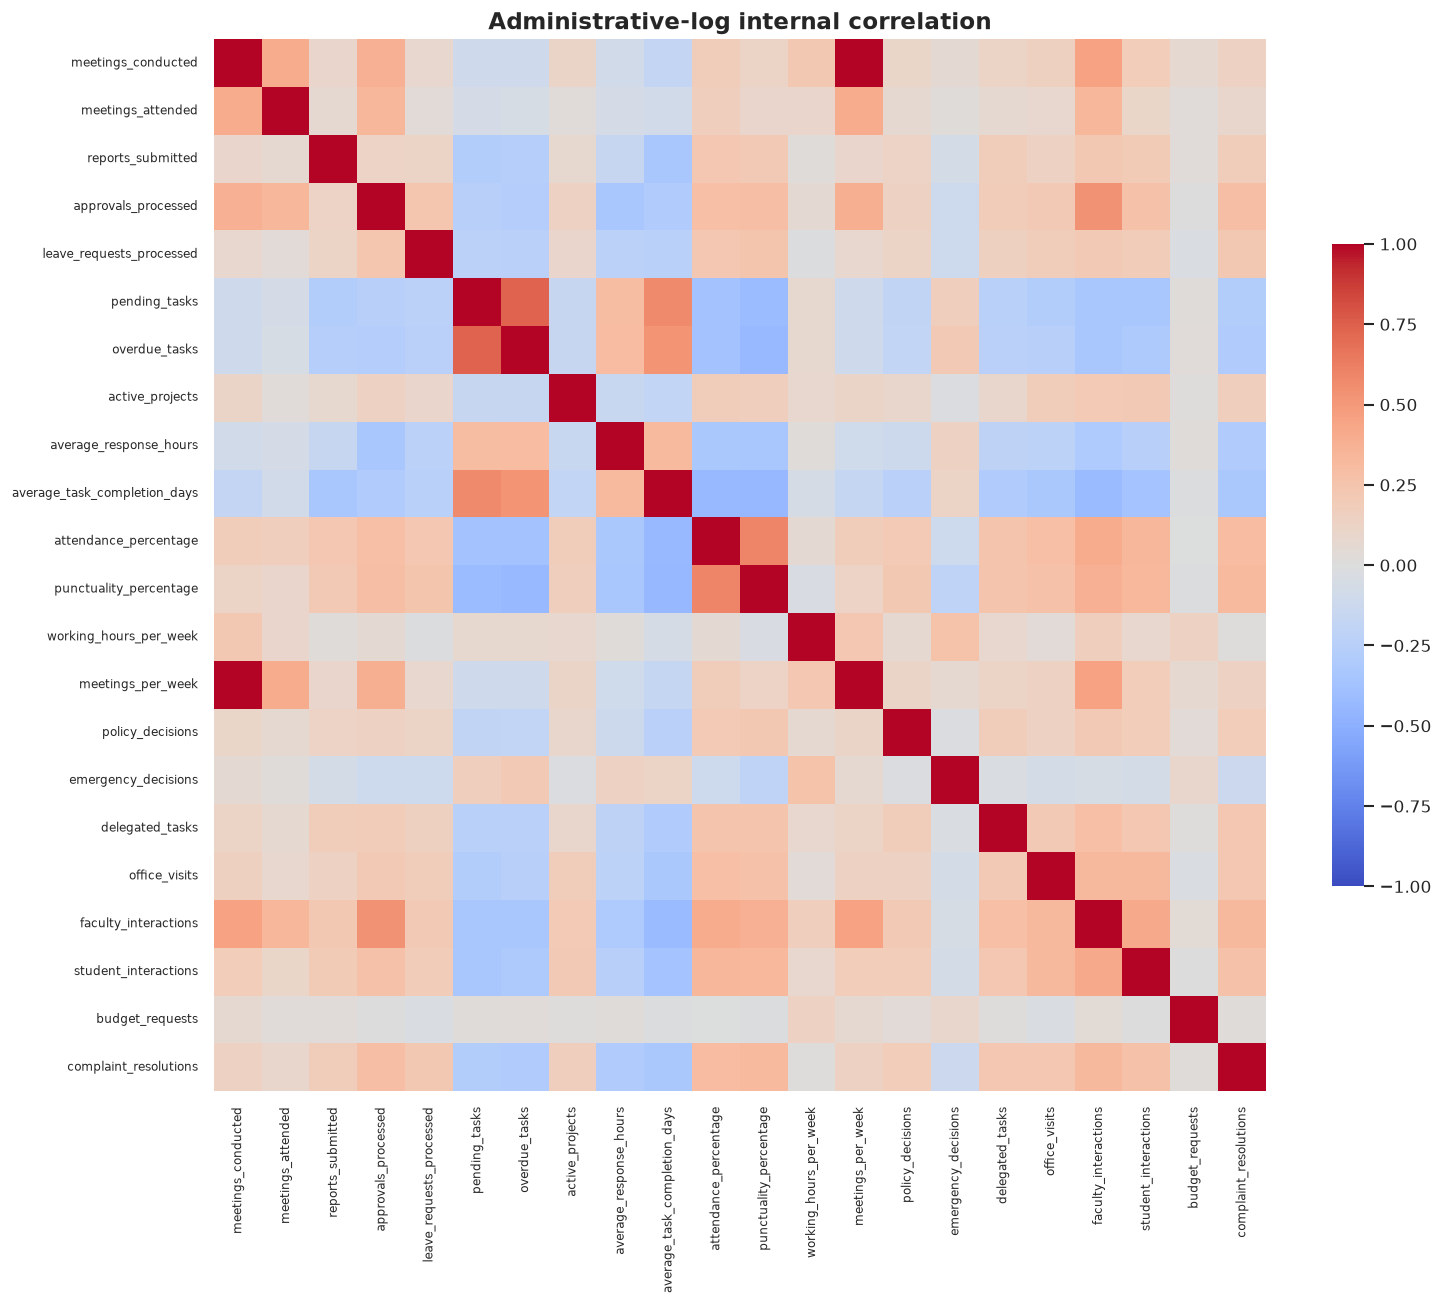


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Meetings attended scale tightly with meetings conducted, and overdue tasks grow with the pending
  backlog — but the overdue fraction widens markedly for high-stress records, revealing stress as an
  operational bottleneck. Emergency decisions and weekly hours rise together, tracing the 'overload'
  dynamic. These intra-modality correlations justify dimensionality reduction before fusion.
════════════════════════════════════════════════════════════════════════════════



In [19]:
# Correlation structure within the log modality.
log_corr = df[LOG_FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(log_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Administrative-log internal correlation"); ax.tick_params(labelsize=7)
save_fig(fig, "section09_log_corr"); plt.show()
insight("""
Meetings attended scale tightly with meetings conducted, and overdue tasks grow with the pending
backlog — but the overdue fraction widens markedly for high-stress records, revealing stress as an
operational bottleneck. Emergency decisions and weekly hours rise together, tracing the 'overload'
dynamic. These intra-modality correlations justify dimensionality reduction before fusion.
""")

# 10 — Survey (Psychometric) Exploration

We explore the teacher-survey modality: the ranking of item means, the inter-item correlation
structure, the raw Likert response distribution per item (stacked), and rating dispersion (the `_std`
aggregates) as a proxy for consensus versus disagreement among teachers.

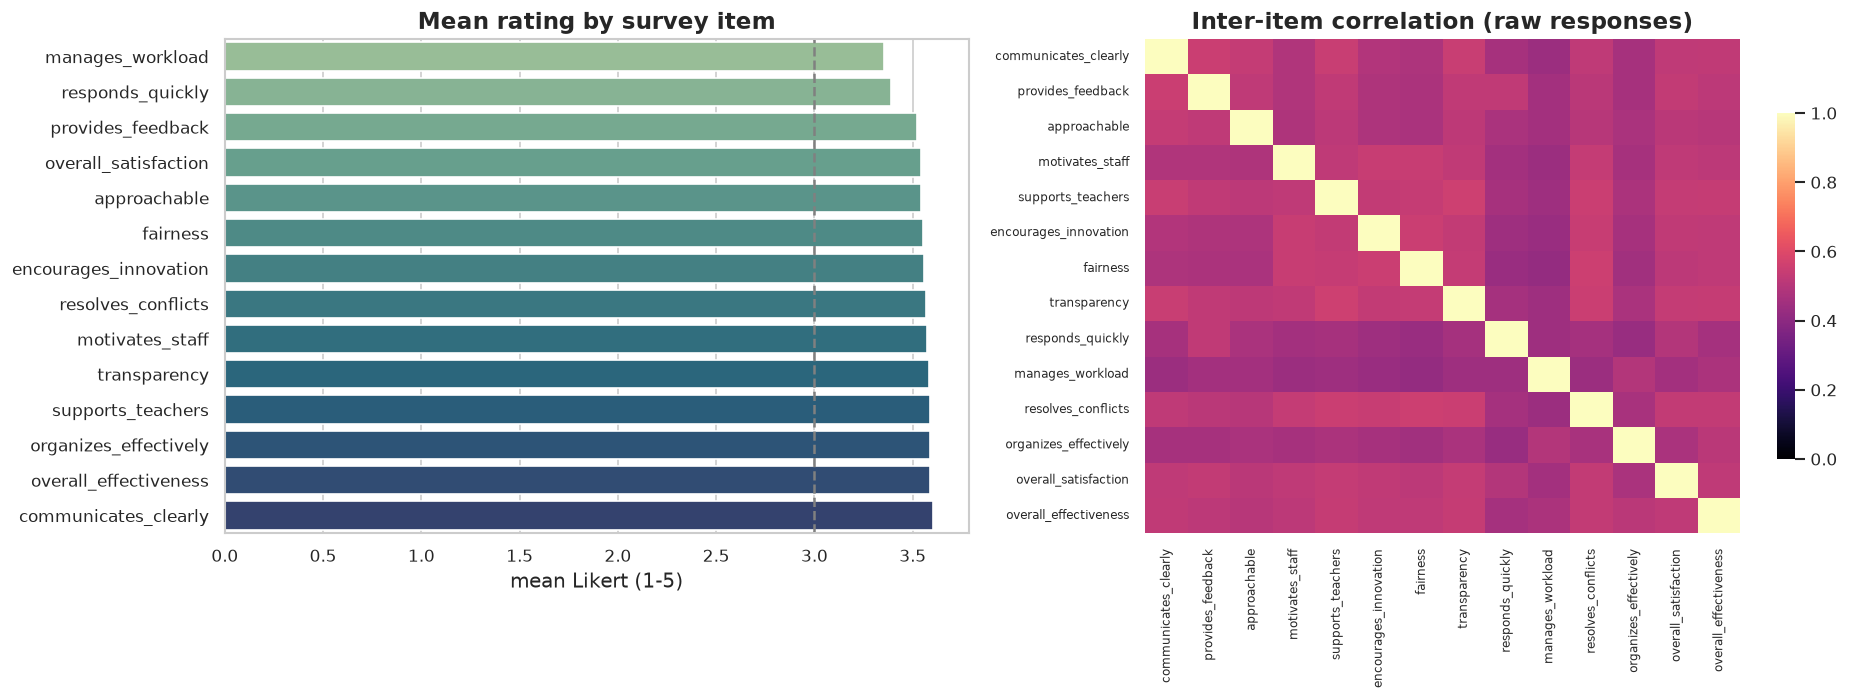

In [20]:
# Item mean ranking.
item_means = df[SURVEY_MEAN_COLS].mean().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=item_means.values, y=[c.replace("_mean", "") for c in item_means.index],
            ax=axes[0], palette="crest")
axes[0].set_title("Mean rating by survey item"); axes[0].set_xlabel("mean Likert (1-5)")
axes[0].axvline(3, color="grey", ls="--")

# Inter-item correlation (raw responses).
iic = survey[SURVEY_ITEMS].corr()
sns.heatmap(iic, cmap="magma", vmin=0, vmax=1, ax=axes[1], cbar_kws={"shrink": 0.7})
axes[1].set_title("Inter-item correlation (raw responses)"); axes[1].tick_params(labelsize=7)
save_fig(fig, "section10_survey_items"); plt.show()

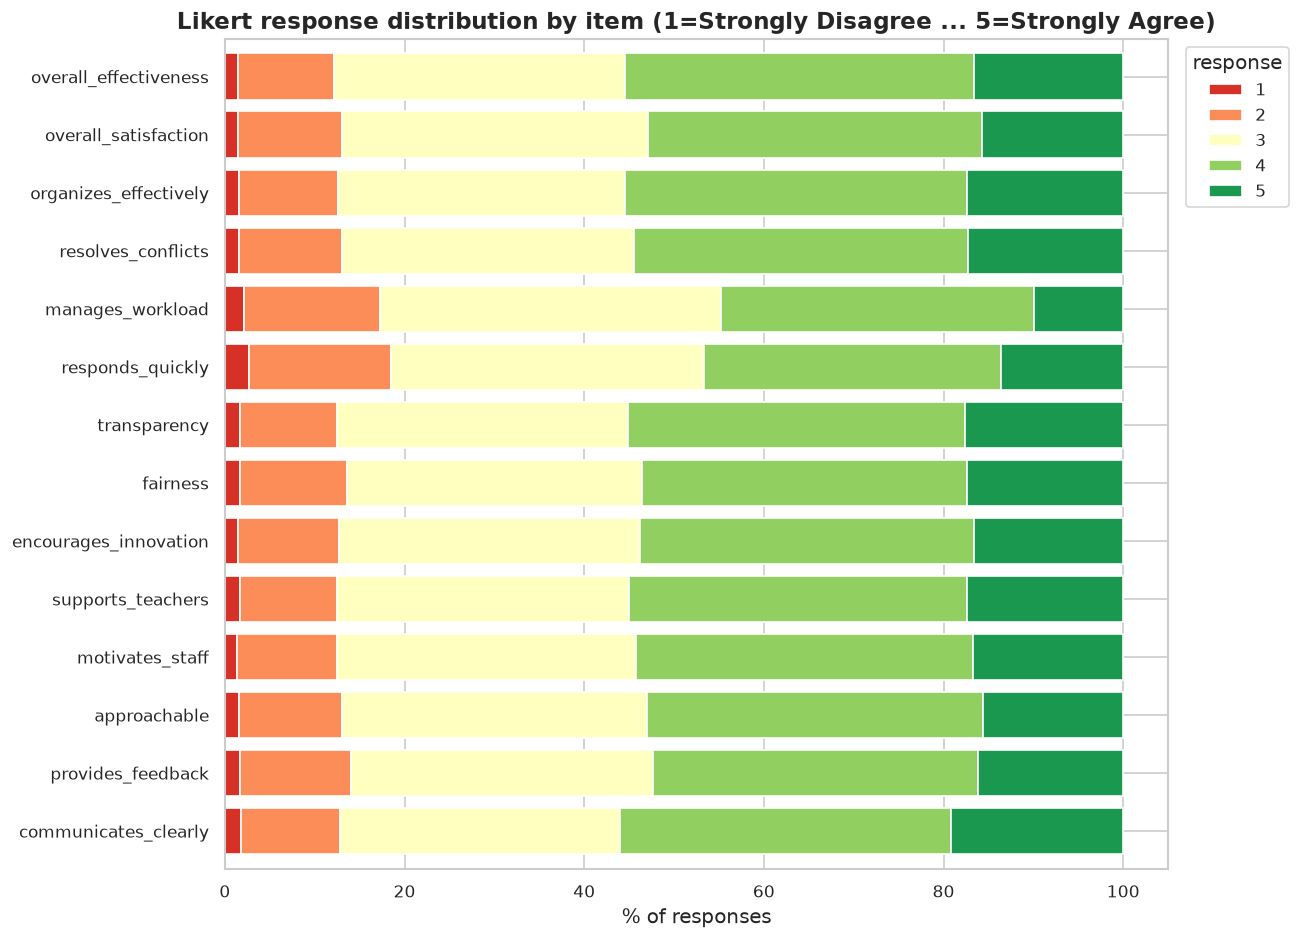

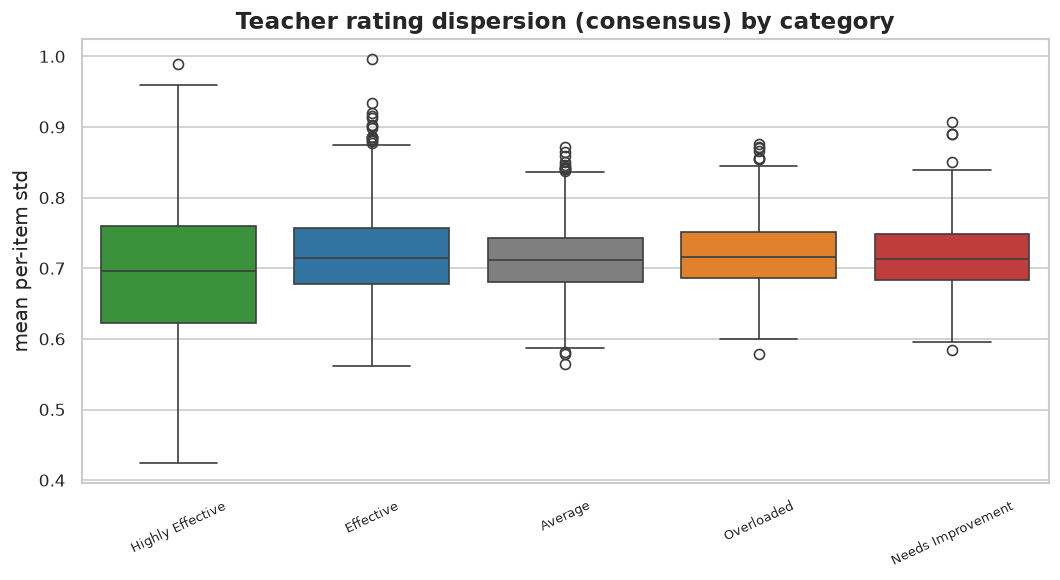


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Items load onto a single coherent construct (uniformly positive inter-item correlations), and the
  stacked distributions skew toward Agree/Strongly-Agree with a realistic minority of dissent. Rating
  dispersion is highest for mid-range categories and lowest at the extremes — teachers agree strongly
  about clearly excellent or clearly struggling administrators, and disagree more about average ones.
════════════════════════════════════════════════════════════════════════════════



In [21]:
# Stacked Likert response distribution per item.
resp_dist = pd.DataFrame({
    it: survey[it].value_counts(normalize=True).reindex([1, 2, 3, 4, 5]).fillna(0) * 100
    for it in SURVEY_ITEMS
}).T[[1, 2, 3, 4, 5]]
likert_colors = ["#d73027", "#fc8d59", "#ffffbf", "#91cf60", "#1a9850"]
fig, ax = plt.subplots(figsize=(11, 8))
resp_dist.plot(kind="barh", stacked=True, color=likert_colors, ax=ax, width=0.8)
ax.set_title("Likert response distribution by item (1=Strongly Disagree ... 5=Strongly Agree)")
ax.set_xlabel("% of responses"); ax.legend(title="response", bbox_to_anchor=(1.01, 1), loc="upper left")
save_fig(fig, "section10_likert_stacked"); plt.show()
savetable(resp_dist.round(2), "section10_likert_distribution")

# Rating dispersion (consensus) by category.
std_cols = [f"{it}_std" for it in SURVEY_ITEMS if f"{it}_std" in df.columns]
if std_cols:
    df["_mean_rating_std"] = df[std_cols].mean(axis=1)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=df, x=CATEGORY_COL, y="_mean_rating_std", order=CATEGORY_ORDER,
                palette=CATEGORY_COLORS, ax=ax)
    ax.set_title("Teacher rating dispersion (consensus) by category")
    ax.set_ylabel("mean per-item std"); ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=25, labelsize=8)
    save_fig(fig, "section10_consensus"); plt.show()
    df.drop(columns="_mean_rating_std", inplace=True)
insight("""
Items load onto a single coherent construct (uniformly positive inter-item correlations), and the
stacked distributions skew toward Agree/Strongly-Agree with a realistic minority of dissent. Rating
dispersion is highest for mid-range categories and lowest at the extremes — teachers agree strongly
about clearly excellent or clearly struggling administrators, and disagree more about average ones.
""")

# 11 — Text-Modality Exploration

Working at the document level, we explore communication volume, length, sentiment and readability,
how sentiment differs across behaviour categories and communication types, the topic/urgency mix, and
the corpus vocabulary via a word cloud.

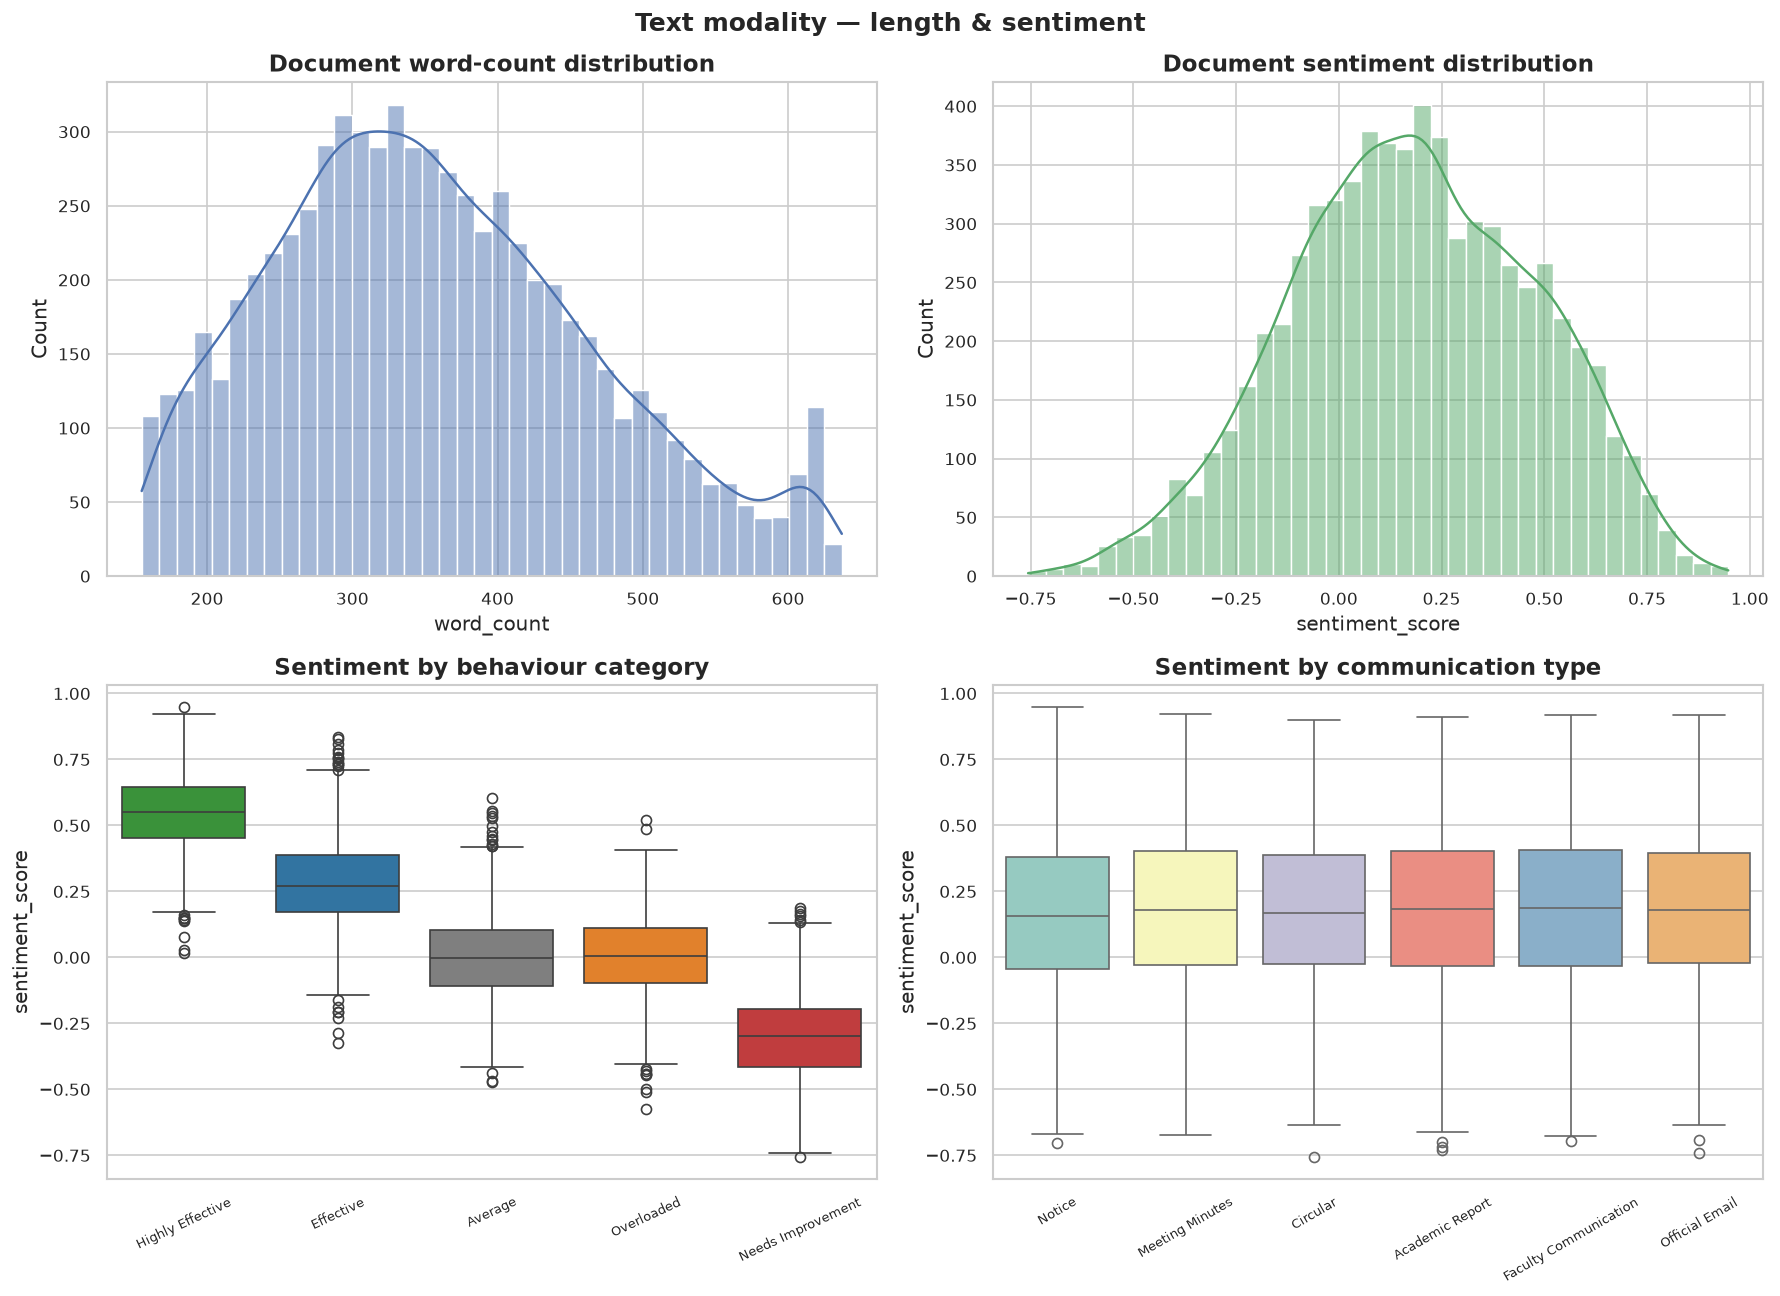

In [22]:
# Merge behaviour category onto documents for grouped views.
text_cat = text.merge(df[["admin_id", "month", CATEGORY_COL]], on=["admin_id", "month"], how="left")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sns.histplot(text["word_count"], bins=40, kde=True, ax=axes[0, 0], color=PALETTE[0])
axes[0, 0].set_title("Document word-count distribution")
sns.histplot(text["sentiment_score"], bins=40, kde=True, ax=axes[0, 1], color=PALETTE[2])
axes[0, 1].set_title("Document sentiment distribution")
sns.boxplot(data=text_cat, x=CATEGORY_COL, y="sentiment_score", order=CATEGORY_ORDER,
            palette=CATEGORY_COLORS, ax=axes[1, 0])
axes[1, 0].set_title("Sentiment by behaviour category"); axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", labelrotation=25, labelsize=8)
if "communication_type" in text.columns:
    sns.boxplot(data=text, x="communication_type", y="sentiment_score", ax=axes[1, 1], palette="Set3")
    axes[1, 1].set_title("Sentiment by communication type"); axes[1, 1].set_xlabel("")
    axes[1, 1].tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("Text modality — length & sentiment", fontsize=15, fontweight="bold")
save_fig(fig, "section11_text_overview"); plt.show()

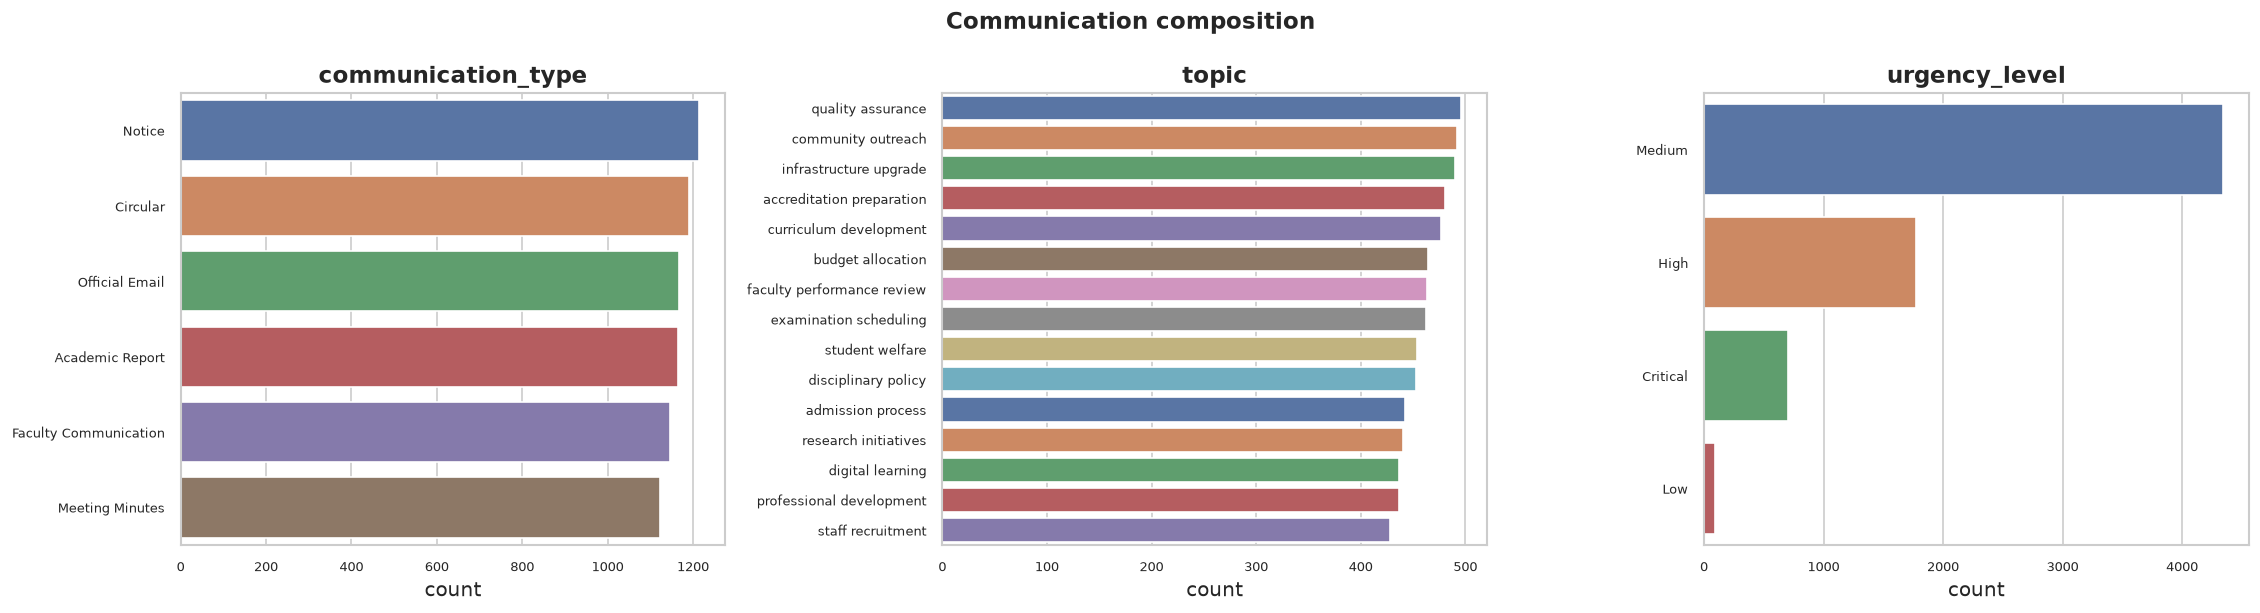

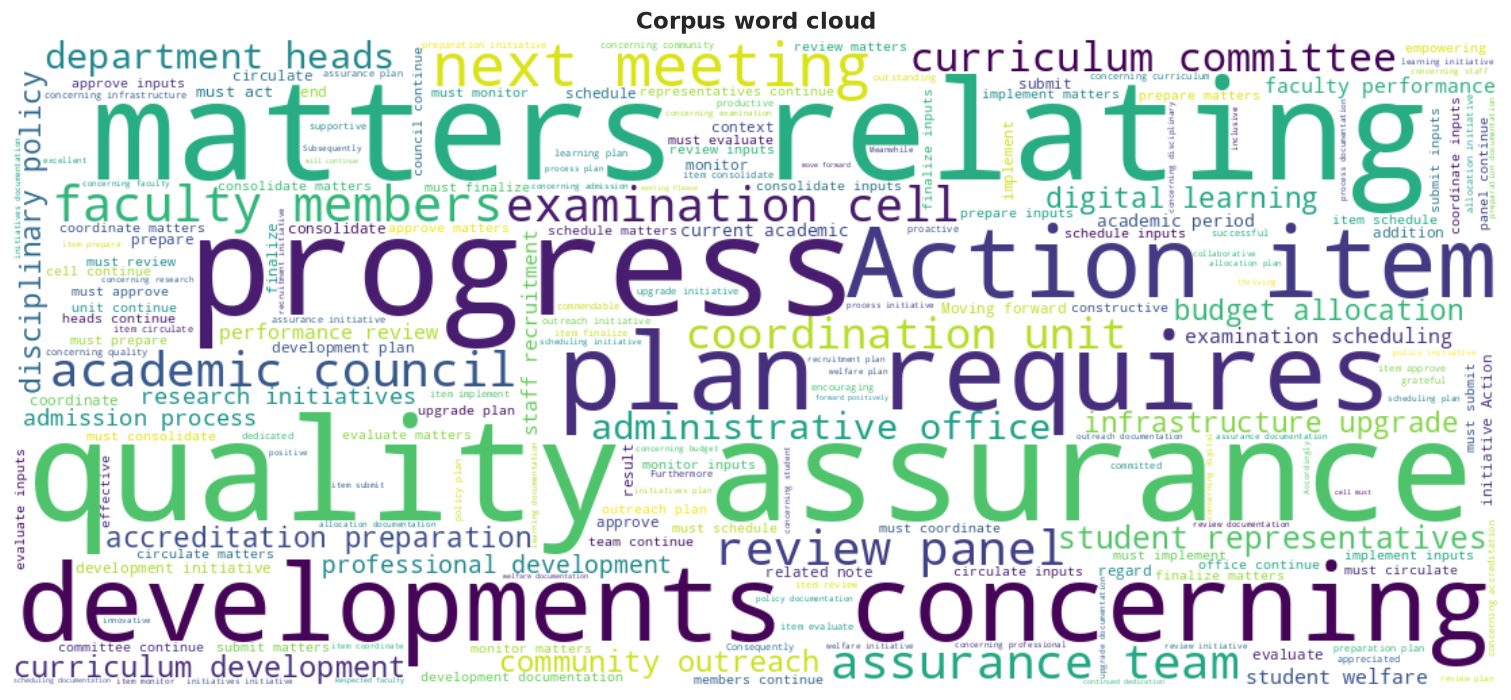


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Document length clusters in the intended 150-600 word band and sentiment is centred slightly positive
  with a clear left tail. Sentiment differs sharply by category — Highly-Effective communication is
  markedly more positive than Needs-Improvement — and 'Notice'/'Circular' types carry more neutral-to-
  negative tone than supportive faculty communication, mirroring real administrative register.
════════════════════════════════════════════════════════════════════════════════



In [23]:
# Communication type, topic and urgency composition.
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
for ax, col in zip(axes, ["communication_type", "topic", "urgency_level"]):
    if col in text.columns:
        order = text[col].value_counts().index
        sns.countplot(data=text, y=col, order=order, ax=ax, palette="deep")
        ax.set_title(col); ax.set_xlabel("count"); ax.set_ylabel(""); ax.tick_params(labelsize=8)
fig.suptitle("Communication composition", fontsize=14, fontweight="bold")
save_fig(fig, "section11_composition"); plt.show()

# Word cloud of the corpus.
try:
    from wordcloud import WordCloud, STOPWORDS
    corpus = " ".join(text["document_text"].dropna().astype(str).sample(
        min(2000, text["document_text"].notna().sum()), random_state=42))
    wc = WordCloud(width=1100, height=480, background_color="white",
                   stopwords=set(STOPWORDS), colormap="viridis").generate(corpus)
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title("Corpus word cloud", fontweight="bold")
    save_fig(fig, "section11_wordcloud"); plt.show()
except Exception as e:
    print("Word cloud skipped:", e)
insight("""
Document length clusters in the intended 150-600 word band and sentiment is centred slightly positive
with a clear left tail. Sentiment differs sharply by category — Highly-Effective communication is
markedly more positive than Needs-Improvement — and 'Notice'/'Circular' types carry more neutral-to-
negative tone than supportive faculty communication, mirroring real administrative register.
""")

# 12 — Temporal Exploration

Because behaviour evolves over the academic year, we chart mean scores across the twelve months
overall and by category, examine calendar seasonality in workload and stress (the fingerprints of
scheduled events such as exams and semester starts), and visualise an administrator × month heatmap.

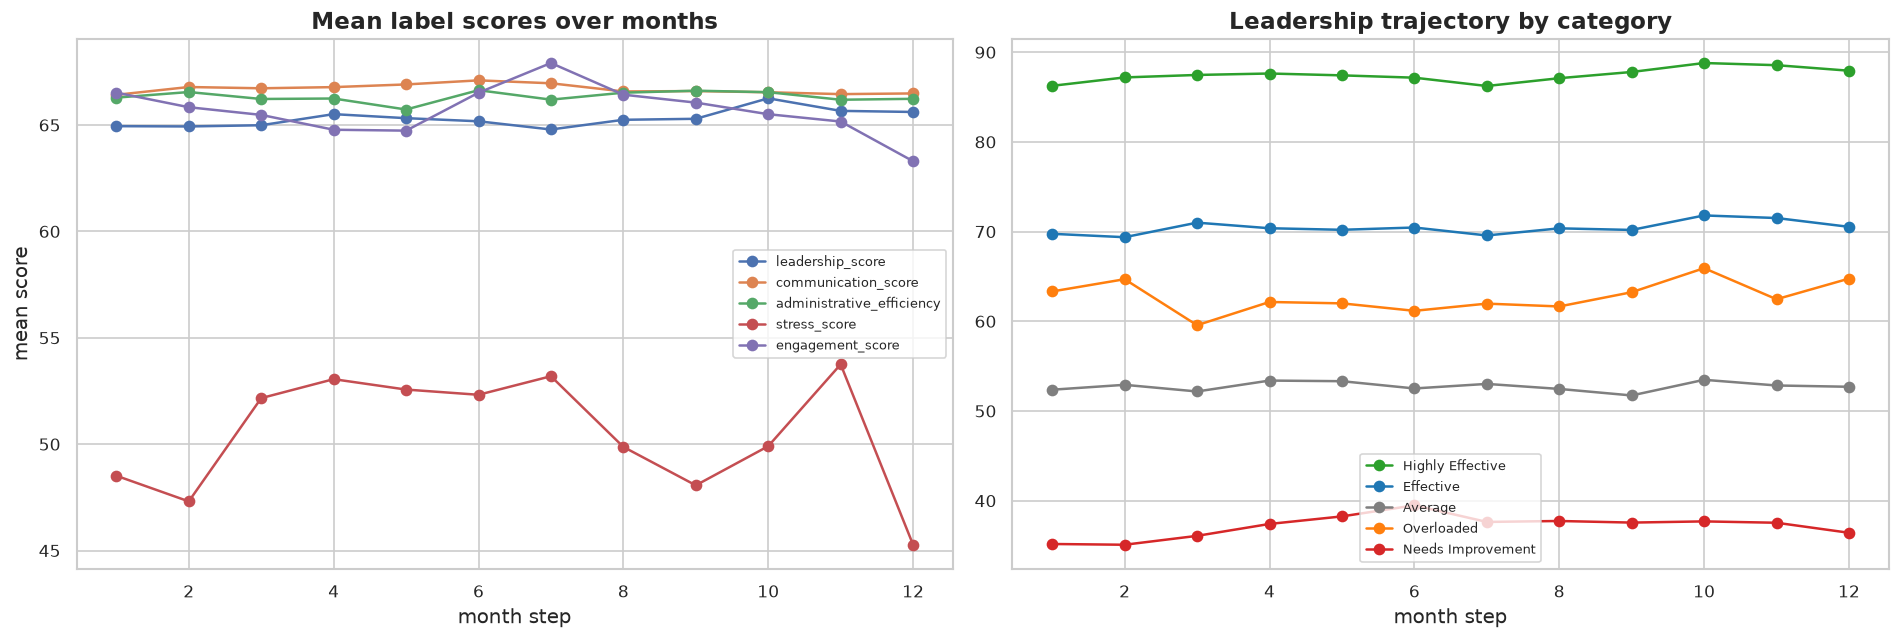

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
monthly = df.groupby("month_step")[LABEL_SCORES].mean()
for score in LABEL_SCORES:
    axes[0].plot(monthly.index, monthly[score], marker="o", label=score)
axes[0].set_title("Mean label scores over months"); axes[0].set_xlabel("month step")
axes[0].set_ylabel("mean score"); axes[0].legend(fontsize=8)

lead_by_cat = df.groupby(["month_step", CATEGORY_COL])["leadership_score"].mean().unstack()
for cat in CATEGORY_ORDER:
    if cat in lead_by_cat.columns:
        axes[1].plot(lead_by_cat.index, lead_by_cat[cat], marker="o",
                     color=CATEGORY_COLORS[cat], label=cat)
axes[1].set_title("Leadership trajectory by category"); axes[1].set_xlabel("month step")
axes[1].legend(fontsize=8)
save_fig(fig, "section12_trends"); plt.show()

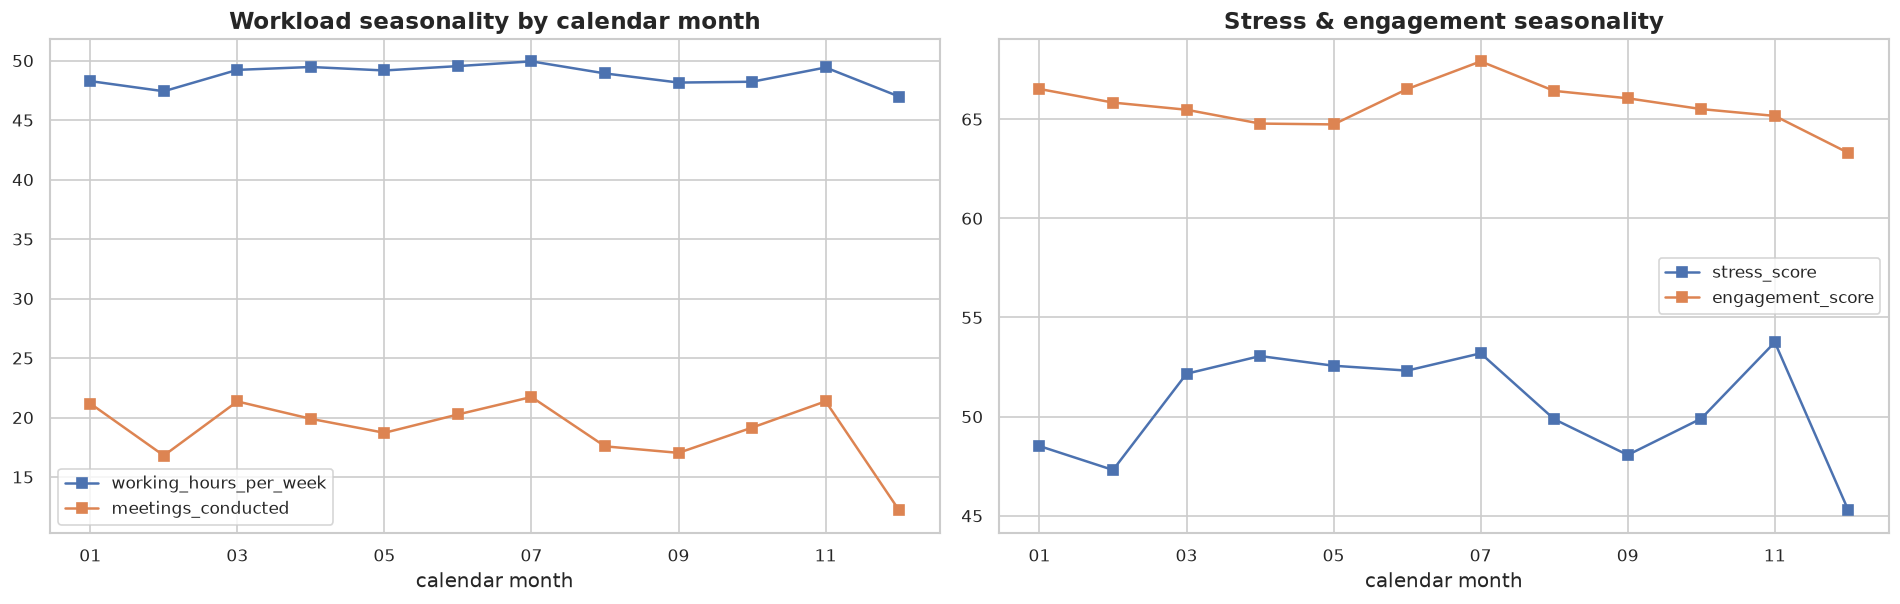

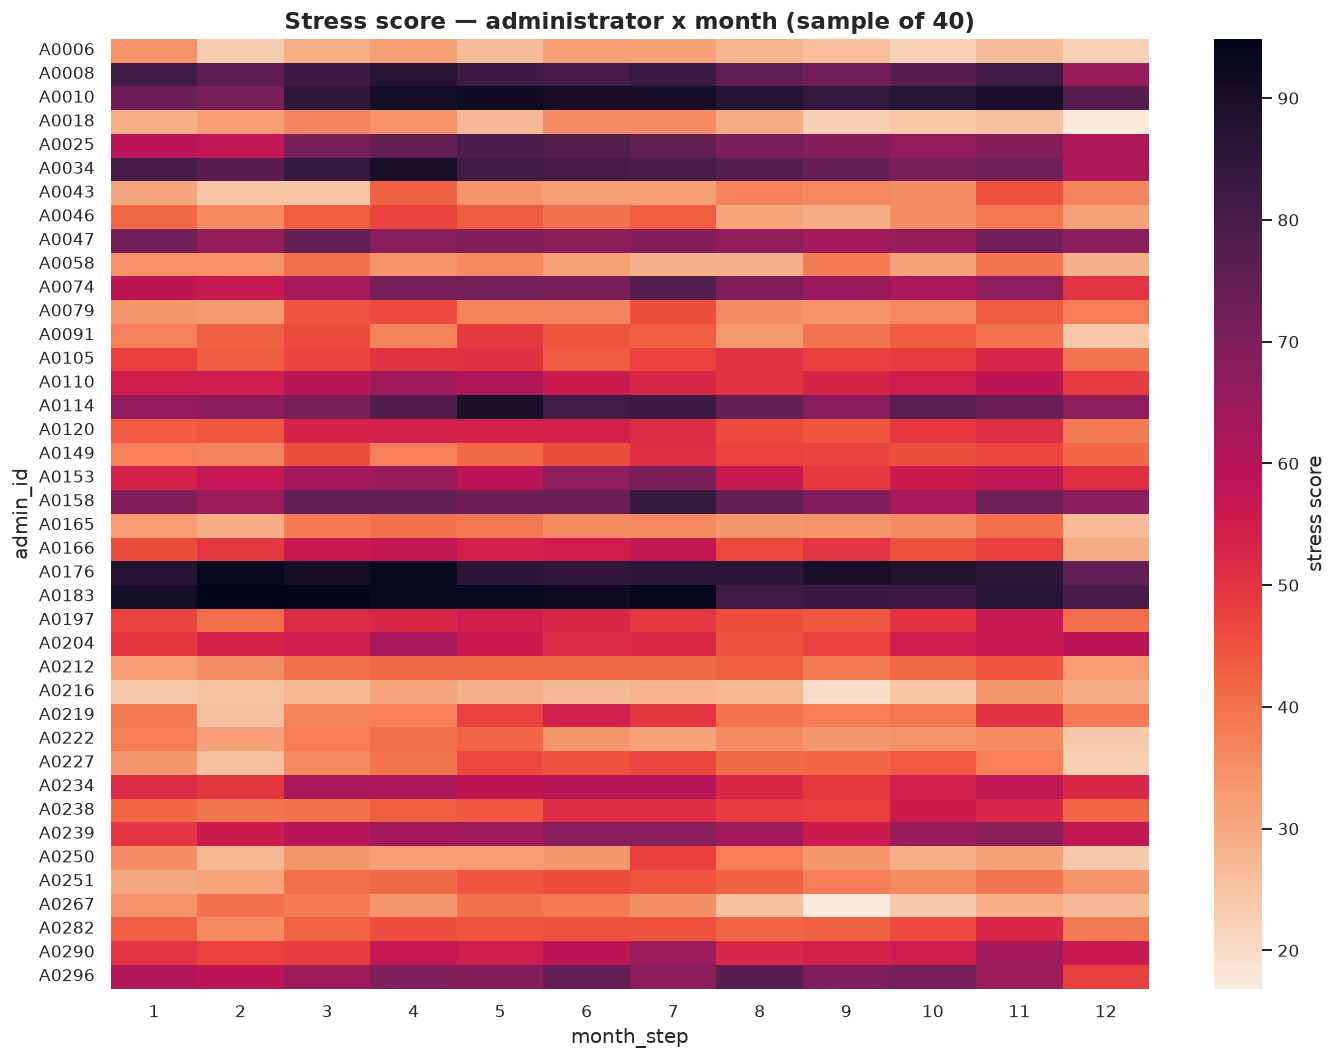


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  Workload, meetings and stress rise around semester-start and examination months and dip during the
  holiday period, producing the intended seasonal rhythm. Category trajectories stay well separated
  across the year (no convergence), confirming stable behavioural identity with realistic month-to-month
  variation — valuable structure for temporal/sequence modelling.
════════════════════════════════════════════════════════════════════════════════



In [25]:
# Calendar seasonality of workload & stress.
df["_cal_month"] = df["month"].astype(str).str[-2:]
seasonal = df.groupby("_cal_month")[["working_hours_per_week", "stress_score",
                                     "meetings_conducted", "engagement_score"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
seasonal[["working_hours_per_week", "meetings_conducted"]].plot(marker="s", ax=axes[0])
axes[0].set_title("Workload seasonality by calendar month"); axes[0].set_xlabel("calendar month")
seasonal[["stress_score", "engagement_score"]].plot(marker="s", ax=axes[1])
axes[1].set_title("Stress & engagement seasonality"); axes[1].set_xlabel("calendar month")
save_fig(fig, "section12_seasonality"); plt.show()
df.drop(columns="_cal_month", inplace=True)

# Administrator x month heatmap (sample of admins).
sample_ids = df["admin_id"].drop_duplicates().sample(40, random_state=42)
pivot = df[df["admin_id"].isin(sample_ids)].pivot_table(
    index="admin_id", columns="month_step", values="stress_score")
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "stress score"})
ax.set_title("Stress score — administrator x month (sample of 40)")
save_fig(fig, "section12_heatmap"); plt.show()
insight("""
Workload, meetings and stress rise around semester-start and examination months and dip during the
holiday period, producing the intended seasonal rhythm. Category trajectories stay well separated
across the year (no convergence), confirming stable behavioural identity with realistic month-to-month
variation — valuable structure for temporal/sequence modelling.
""")

# 13 — Interactive Visual Analytics (Plotly)

A set of interactive charts for deeper exploration: a cross-modal scatter (text sentiment vs teacher
satisfaction), a demographic sunburst, an interactive score time-series, and a 3-D view of the label
space. Each is saved as a standalone HTML file under `output/eda/interactive/`.

In [26]:
plot_df = df.dropna(subset=["text_avg_sentiment", "overall_satisfaction_mean", "leadership_score"]).copy()
plot_df[CATEGORY_COL] = plot_df[CATEGORY_COL].astype(str)
fig = px.scatter(
    plot_df, x="text_avg_sentiment", y="overall_satisfaction_mean",
    color=CATEGORY_COL, size="leadership_score", size_max=14,
    category_orders={CATEGORY_COL: CATEGORY_ORDER}, color_discrete_map=CATEGORY_COLORS,
    hover_data=["admin_id", "month", "stress_score"], opacity=0.65,
    title="Text sentiment vs teacher satisfaction (size = leadership)")
fig.update_layout(width=1000, height=600)
save_plotly(fig, "section13_scatter_sentiment_satisfaction")
fig

In [27]:
# Demographic sunburst.
if all(c in df.columns for c in ["institution_type", "department"]):
    sb = df.copy(); sb[CATEGORY_COL] = sb[CATEGORY_COL].astype(str)
    fig = px.sunburst(sb, path=["institution_type", "department", CATEGORY_COL],
                      color=CATEGORY_COL, color_discrete_map=CATEGORY_COLORS,
                      title="Population composition: institution -> department -> behaviour")
    fig.update_layout(width=850, height=750)
    save_plotly(fig, "section13_sunburst")
    display(fig)

# Interactive mean-score time series.
ts = df.groupby("month_step")[LABEL_SCORES].mean().reset_index().melt(
    id_vars="month_step", var_name="score", value_name="mean")
fig = px.line(ts, x="month_step", y="mean", color="score", markers=True,
              title="Mean behavioural scores over time (interactive)")
fig.update_layout(width=1000, height=550)
save_plotly(fig, "section13_timeseries")
fig

In [28]:
# 3-D label space.
s3 = df.dropna(subset=["leadership_score", "communication_score", "stress_score"]).copy()
s3[CATEGORY_COL] = s3[CATEGORY_COL].astype(str)
s3 = s3.sample(min(1500, len(s3)), random_state=42)
fig = px.scatter_3d(s3, x="leadership_score", y="communication_score", z="stress_score",
                    color=CATEGORY_COL, color_discrete_map=CATEGORY_COLORS,
                    category_orders={CATEGORY_COL: CATEGORY_ORDER}, opacity=0.6,
                    title="Behaviour categories in 3-D label space")
fig.update_traces(marker_size=3.5); fig.update_layout(width=950, height=700)
save_plotly(fig, "section13_scatter3d")
fig

# 14 — Multidimensional View (PCA)

Principal Component Analysis compresses the numeric feature space to reveal its dominant axes of
variation, how much structure the leading components capture, which features load most strongly, and
whether the behaviour categories separate in the principal-component plane.

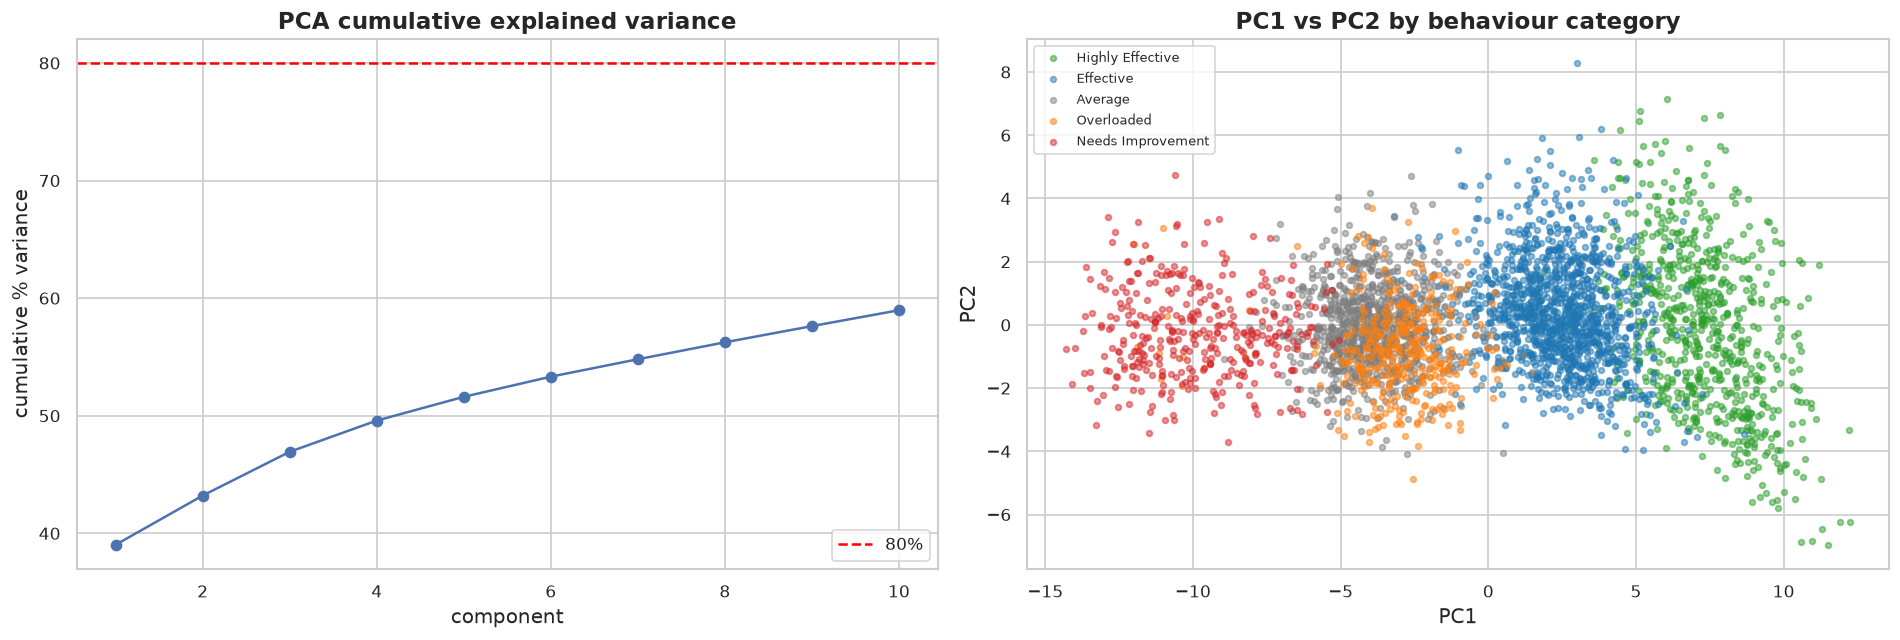

In [29]:
pca_features = [c for c in NUMERIC_COLS if df[c].notna().sum() > len(df) * 0.6]
Xp = StandardScaler().fit_transform(df[pca_features].fillna(df[pca_features].median()))
pca = PCA(n_components=10, random_state=42).fit(Xp)
scores2 = PCA(n_components=2, random_state=42).fit_transform(Xp)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, marker="o")
axes[0].axhline(80, color="red", ls="--", label="80%")
axes[0].set_title("PCA cumulative explained variance")
axes[0].set_xlabel("component"); axes[0].set_ylabel("cumulative % variance"); axes[0].legend()

cats = df[CATEGORY_COL].astype(str).values
for cat in CATEGORY_ORDER:
    m = cats == cat
    axes[1].scatter(scores2[m, 0], scores2[m, 1], s=12, alpha=0.5,
                    color=CATEGORY_COLORS[cat], label=cat)
axes[1].set_title("PC1 vs PC2 by behaviour category")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend(fontsize=8)
save_fig(fig, "section14_pca"); plt.show()

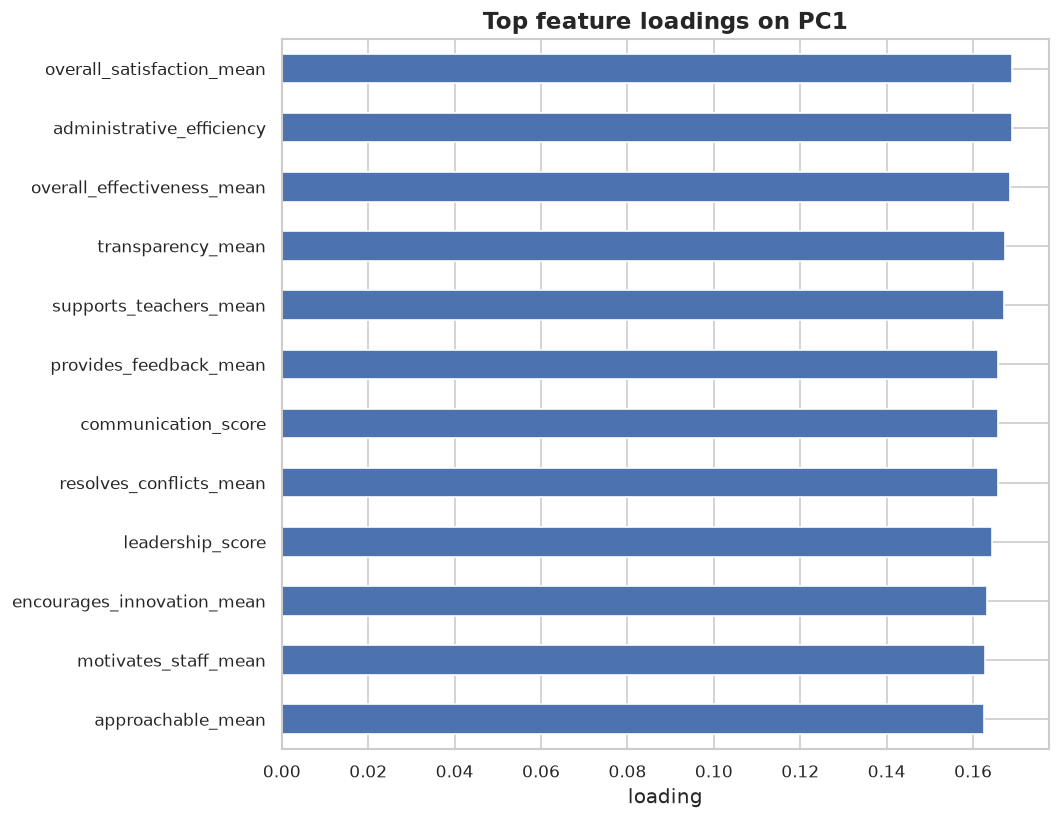


════════════════════════════════════════════════════════════════════════════════
INSIGHT
────────────────────────────────────────────────────────────────────────────────
  The first two components capture 43% of variance and
  1 components exceed 80%. PC1 is a general
  'effectiveness' axis (competence scores and positive survey items load together, opposed by stress /
  overdue tasks), along which the categories order cleanly — evidence of a strong, low-dimensional latent
  structure ideally suited to representation learning.
════════════════════════════════════════════════════════════════════════════════



In [30]:
# Top loadings on the first two components.
loadings = pd.DataFrame(pca.components_[:2].T, index=pca_features, columns=["PC1", "PC2"])
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(12).index
fig, ax = plt.subplots(figsize=(9, 7))
loadings.loc[top_pc1, "PC1"].sort_values().plot(kind="barh", ax=ax, color=PALETTE[0])
ax.set_title("Top feature loadings on PC1"); ax.set_xlabel("loading")
save_fig(fig, "section14_loadings"); plt.show()
savetable(loadings.round(4), "section14_pca_loadings")
insight(f"""
The first two components capture {np.cumsum(pca.explained_variance_ratio_)[1]*100:.0f}% of variance and
{np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.8)+1} components exceed 80%. PC1 is a general
'effectiveness' axis (competence scores and positive survey items load together, opposed by stress /
overdue tasks), along which the categories order cleanly — evidence of a strong, low-dimensional latent
structure ideally suited to representation learning.
""")

# 15 — Key Insights & Takeaways

A consolidated summary of the exploratory findings and their implications for the transformer-based
multimodal fusion modelling that follows.

In [31]:
takeaways = [
    "Class imbalance is deliberate and intact (Effective largest; Overloaded / Needs-Improvement rare) "
    "-> use stratified splits and macro-averaged / imbalance-aware metrics.",
    "Label scores are inter-correlated and rise monotonically across categories, while stress uniquely "
    "peaks for the Overloaded profile -> the target encodes a coherent, ordered latent construct.",
    "Cross-modal relationships are strong and directional (response time-, sentiment+, overdue-, "
    "attendance+) -> multimodal fusion is well-motivated; each modality adds complementary signal.",
    "Administrative counts / latencies are right-skewed (Poisson / Log-Normal) -> apply log or rank "
    "transforms for linear models; tree/transformer models can ingest as-is.",
    "Survey items form a single reliable construct with realistic leniency skew and category-dependent "
    "consensus -> aggregate item means are high-value features.",
    "Text sentiment / length / readability separate categories and communication types -> language "
    "embeddings should contribute meaningfully to fusion.",
    "Behaviour evolves smoothly with clear academic-calendar seasonality -> temporal / sequence "
    "context is exploitable.",
    "Demographics are near non-predictive (tiny eta^2) -> low embedded bias; safe to include or exclude.",
    "PCA shows a dominant low-dimensional 'effectiveness' axis -> strong latent structure amenable to "
    "representation learning.",
]
summary = pd.DataFrame({"#": range(1, len(takeaways) + 1), "insight": takeaways})
savetable(summary, "section15_key_insights", index=False)
for t in takeaways:
    print("\u2022 " + fill(t, 110, subsequent_indent="  "))

• Class imbalance is deliberate and intact (Effective largest; Overloaded / Needs-Improvement rare) -> use
  stratified splits and macro-averaged / imbalance-aware metrics.
• Label scores are inter-correlated and rise monotonically across categories, while stress uniquely peaks for
  the Overloaded profile -> the target encodes a coherent, ordered latent construct.
• Cross-modal relationships are strong and directional (response time-, sentiment+, overdue-, attendance+) ->
  multimodal fusion is well-motivated; each modality adds complementary signal.
• Administrative counts / latencies are right-skewed (Poisson / Log-Normal) -> apply log or rank transforms for
  linear models; tree/transformer models can ingest as-is.
• Survey items form a single reliable construct with realistic leniency skew and category-dependent consensus ->
  aggregate item means are high-value features.
• Text sentiment / length / readability separate categories and communication types -> language embeddings
  s

In [32]:
# Inventory of all generated EDA artefacts.
print("EDA artefacts written under output/eda/:\n")
for sub, label in [(FIG_DIR, "figures (.png)"), (TABLE_DIR, "tables (.csv)"),
                   (HTML_DIR, "interactive (.html)")]:
    files = sorted(f for f in sub.glob("*") if f.is_file())
    print(f"{label}: {len(files)}")
    for f in files:
        print(f"    {f.name}")
print("\nEDA complete.")

EDA artefacts written under output/eda/:

figures (.png): 29
    section01_feature_inventory.png
    section02_missing_by_feature.png
    section03_dist_labels.png
    section03_dist_logs.png
    section03_dist_survey.png
    section03_dist_text.png
    section04_categoricals.png
    section05_score_pairplot.png
    section05_scores_by_category.png
    section06_bivariate.png
    section06_corr_heatmap.png
    section06_leadership_drivers.png
    section07_category_heatmap.png
    section07_radar.png
    section08_demographics.png
    section08_experience_age.png
    section09_log_corr.png
    section09_logs.png
    section10_consensus.png
    section10_likert_stacked.png
    section10_survey_items.png
    section11_composition.png
    section11_text_overview.png
    section11_wordcloud.png
    section12_heatmap.png
    section12_seasonality.png
    section12_trends.png
    section14_loadings.png
    section14_pca.png
tables (.csv): 10
    section01_column_glimpse.csv
    section02_mis

---

### End of EDA

This notebook explored the synthetic multimodal dataset across fifteen thematic sections, persisting
every figure, table and interactive chart under `output/eda/`. The analysis confirms rich, coherent,
low-bias multimodal structure with exploitable temporal dynamics — a sound empirical basis for the
transformer-based fusion modelling stage.